# Kinematics: Adam MAP + broad-prior MCMC posterior

Focused fitting notebook: Adam initializes the kinematic model, then MCMC samples the same full-image R-minus-C objective with broad proper priors. Poster figures live in `poster-plots.ipynb`. Set `ID` and `N_CORES` in the next cell.


In [34]:
# Pick up edits to dingo/*.py without restarting the kernel. Without this,
# Python caches the module from first import and later fixes are invisible.
%load_ext autoreload
%autoreload 2

# ===========================================================================
# Edit these two.
# ===========================================================================
ID      = 15665
N_CORES = 6          # CPU workers / threads for torch / BLAS / JAX

# Pipeline switches. All False = load everything already on disk and just plot.
RUN_PYSERSIC       = True     # fit/load the morphology before kinematics (~4 min)
USE_PYSERSIC_PRIOR = False    # unused in fixed-inclination mode
FIX_INCLINATION    = True     # hold i to the adopted photometric value
FIXED_INC_RAD      = None     # filled from the pysersic posterior below
FIXED_INC_SIGMA    = None     # filled from the pysersic posterior/method scatter
RUN_MCMC           = False     # True = sample; False = load the saved chain
RERUN_MCMC         = False     # True = delete this run's chain/checkpoint and start fresh
MCMC_USE_POOL      = True     # parallelize emcee walker likelihood calls
MCMC_PROCESSES     = N_CORES  # one PyTorch thread per worker

# Sources to process in the batch section at the bottom. [] = just ID above.
BATCH_IDS = []               # e.g. SAMPLE_IDS, or [3700, 6170]

import os

# Thread limits must be set BEFORE torch, numpy's BLAS or JAX are imported --
# they are read once at import time and ignored if changed afterwards.
for _v in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'OPENBLAS_NUM_THREADS',
           'NUMEXPR_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ[_v] = str(N_CORES)
os.environ['XLA_FLAGS'] = (f'--xla_force_host_platform_device_count={N_CORES} '
                           f'intra_op_parallelism_threads={N_CORES}')

import sys, glob, logging, numbers, warnings

# ===========================================================================
# Paths. REPO is this repository; the other three are the big shared datasets
# that are far too large to live in git (grism_cal ~15 GB, EDR_data ~18 GB),
# so they stay outside it and you point at wherever they are on this machine.
# Set these four and nothing else needs touching.
# ===========================================================================
REPO      = '/Users/aakavan/Astro_Research/Galaxy_Kinematics/DINGO_development/grism-kinematics'
GRISM_CAL = '/Users/aakavan/Astro_Research/Galaxy_Kinematics/grism_cal'
EDR_DATA  = '/Users/aakavan/Astro_Research/Galaxy_Kinematics/EDR_data'
PSF_DIR   = '/Users/aakavan/Astro_Research/Galaxy_Kinematics/github_backups/galaxy_kinematics/15665/geko_fitting/psfs'

# everything below is derived -- no need to edit
DATA    = os.path.join(REPO, 'data')       # per-source R/C/image + config
RESULTS = os.path.join(REPO, 'results')    # npz + png, one folder per source
LOGS    = os.path.join(REPO, 'logs')       # every log, prefixed with the ID
GK      = EDR_DATA                         # kept for the catalogue lookup below

os.environ['GRISM_CAL_DIR'] = GRISM_CAL
os.environ['SAPPHIRES_CAT_DIR'] = EDR_DATA
sys.path.insert(0, REPO)                   # so `import dingo` finds REPO/dingo

for _label, _p in [('REPO', REPO), ('GRISM_CAL', GRISM_CAL), ('EDR_DATA', EDR_DATA),
                   ('PSF_DIR', PSF_DIR)]:
    if not os.path.exists(_p):
        print(f'WARNING: {_label} does not exist: {_p}')

import numpy as np
import matplotlib.pyplot as plt
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scipy.ndimage
from matplotlib.lines import Line2D
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

from dingo import grism, utils, galaxy, kinematics, fitting, plot

torch.set_num_threads(N_CORES)
plt.rcParams['axes.grid'] = False
plt.rcParams['image.cmap'] = 'gist_heat'
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(message)s', datefmt='%H:%M:%S')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def asinhstretch(im):
    return np.arcsinh(im/sigma_clipped_stats(im)[2])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
# ---------------------------------------------------------------------------
# Catalogue lookup + config generation, inlined so the notebook needs no local
# .py files. Kept in sync with catalogs.py -- this copy now includes
# lookup_module() (3 of the 7 sources are on module B, not A) and SOURCE_HINTS
# (per-source rotation sense and starting values from the grad student's batch).
# ---------------------------------------------------------------------------
LOG = logging.getLogger('kin')
LOG.setLevel(logging.INFO)
SAMPLE_IDS = [3700, 6170, 8910, 15665, 16887, 21619, 21636]
CANDIDATE_DIRS_EXTRA = [EDR_DATA]


SPEC_CAT = 'sapphires_edr_spec_cat.fits'
PHOT_CAT = 'sapphires_edr_phot_cat.fits'

CANDIDATE_DIRS = CANDIDATE_DIRS_EXTRA + [
    '../EDR',            # magnif, relative to the notebook directory
    '../../EDR',
]

_CACHE = {}


def find_cat_dir(cat_dir=None):
    '''Directory holding the two EDR catalogues.'''
    if cat_dir is not None:
        candidates = [cat_dir]
    elif os.environ.get('SAPPHIRES_CAT_DIR'):
        candidates = [os.environ['SAPPHIRES_CAT_DIR']]
    else:
        candidates = CANDIDATE_DIRS
    for d in candidates:
        if os.path.exists(os.path.join(d, SPEC_CAT)):
            return d
    raise FileNotFoundError(
        f'could not find {SPEC_CAT} in any of {candidates}. Pass cat_dir= or set '
        f'$SAPPHIRES_CAT_DIR.')


def _load(cat_dir, name):
    key = (os.path.abspath(cat_dir), name)
    if key not in _CACHE:
        path = os.path.join(cat_dir, name)
        _CACHE[key] = fits.getdata(path)
        LOG.debug(f'loaded {path}')
    return _CACHE[key]


def lookup_source(source_id, cat_dir=None, require_z=True):
    '''
    RA/Dec/redshift for one source ID.

    Returns a dict with:
        id, ra, dec                  -- degrees
        zspec, zconf, nlines, name   -- None if the ID is not in the spec catalogue
        q_phot, pa_phot              -- axis ratio and orientation from the photometric
                                        catalogue's second moments, or None. A crude
                                        sanity check on a Sersic fit's `q`, not a
                                        substitute for one: it is unweighted, uses no
                                        PSF, and is measured on the detection image.
        in_spec_cat, in_phot_cat     -- bool

    require_z=True raises if the ID has no spectroscopic redshift.
    '''
    cat_dir = find_cat_dir(cat_dir)
    source_id = int(source_id)
    out = {'id': source_id, 'cat_dir': cat_dir,
           'ra': None, 'dec': None, 'zspec': None, 'zconf': None,
           'nlines': None, 'name': None, 'q_phot': None, 'pa_phot': None,
           'in_spec_cat': False, 'in_phot_cat': False}

    spec = _load(cat_dir, SPEC_CAT)
    hit = spec[spec['ID'] == source_id]
    if len(hit):
        r = hit[0]
        out.update(in_spec_cat=True,
                   ra=float(r['RA']), dec=float(r['DEC']),
                   zspec=float(r['zspec']), zconf=float(r['zconf']),
                   nlines=int(r['nlines']),
                   name=str(r['name']).strip())

    try:
        phot = _load(cat_dir, PHOT_CAT)
    except FileNotFoundError:
        phot = None
    if phot is not None:
        hit = phot[phot['ID'] == source_id]
        if len(hit):
            r = hit[0]
            out['in_phot_cat'] = True
            if out['ra'] is None:
                out['ra'], out['dec'] = float(r['RA']), float(r['DEC'])
            a, b = float(r['semimajor_sigma']), float(r['semiminor_sigma'])
            if a > 0:
                out['q_phot'] = b/a
            out['pa_phot'] = float(r['orientation'])

    if out['ra'] is None:
        raise KeyError(f'ID {source_id} is in neither {SPEC_CAT} nor {PHOT_CAT} '
                       f'under {cat_dir}')
    if require_z and out['zspec'] is None:
        raise KeyError(f'ID {source_id} has no spectroscopic redshift in {SPEC_CAT}')
    return out


SPEC1D_DIRNAME = 'sapphires_edr_1d_spec'

# Per-source starting values and rotation sense, from the grad student's working
# batch in 1.1-astr540-plot.ipynb. sign = -1 means the galaxy rotates the other
# way; his loop sets V_rot = 300*sign. Starting a sign=-1 galaxy at +V_rot with
# theta_v = 0 makes Adam escape through inc -> 0 (which forces vz = 0 everywhere)
# instead of finding the theta_v ~ pi solution -- that is exactly how ID3700 and
# ID21619 failed here.
SOURCE_HINTS = {
    3700:  {'sign': -1, 'R_v': 4, 'x0_v': 40, 'y0_v': 40},
    6170:  {'sign':  1, 'R_v': 2, 'x0_v': 40, 'y0_v': 40},
    8910:  {'sign':  1, 'R_v': 2, 'x0_v': 40, 'y0_v': 40},
    15665: {'sign': -1, 'R_v': 2, 'x0_v': 40, 'y0_v': 40},
    16887: {'sign':  1, 'R_v': 2, 'x0_v': 40, 'y0_v': 40},
    21619: {'sign': -1, 'R_v': 1, 'x0_v': 44, 'y0_v': 30},
    21636: {'sign':  1, 'R_v': 2, 'x0_v': 40, 'y0_v': 40},
}


def lookup_module(source_id, grism='R', filter='F444W', cat_dir=None):
    '''
    Which NIRCam module a source was observed on, from the EDR 1D spectra.

    The cutouts carry no MODULE keyword, but spec_1d_M0416_<filter>_ID<n>_<R|C>.fits
    records N_A and N_B, the number of coadded exposures per module. Whichever is
    non-zero is the module. This matters: `module` selects the tracing and
    dispersion calibration tables, so guessing it wrong silently gives the wrong
    trace. Three of the seven Pa-alpha sources are on B, not A.

    Returns 'A' or 'B', or None when no spectrum file exists.
    '''
    cat_dir = cat_dir or find_cat_dir()
    path = os.path.join(cat_dir, SPEC1D_DIRNAME,
                        f'spec_1d_M0416_{filter}_ID{int(source_id)}_{grism}.fits')
    if not os.path.exists(path):
        LOG.warning(f'no 1D spectrum at {path}; cannot determine module')
        return None
    h = fits.getheader(path, 1)
    n_a, n_b = h.get('N_A', 0) or 0, h.get('N_B', 0) or 0
    if n_a == n_b:
        LOG.warning(f'ID{source_id} {grism}: N_A == N_B == {n_a}, module ambiguous')
        return None
    return 'A' if n_a > n_b else 'B'


def print_source(src):
    '''Print a lookup_source() result.'''
    print(f"ID {src['id']}")
    print(f"  RA, Dec    = {src['ra']:.6f}, {src['dec']:+.6f} deg")
    if src['zspec'] is not None:
        extra = []
        if src['zconf'] is not None:
            extra.append(f"zconf {src['zconf']:.2f}")
        if src['nlines'] is not None:
            extra.append(f"{src['nlines']} lines")
        if src['name']:
            extra.append(src['name'])
        print(f"  zspec      = {src['zspec']:.4f}" +
              (f"   ({', '.join(extra)})" if extra else ''))
    else:
        print('  zspec      = not in the spec catalogue')
    if src['q_phot'] is not None:
        inc = np.degrees(np.arccos(np.clip(src['q_phot'], 0, 1)))
        print(f"  q (phot cat second moments) = {src['q_phot']:.4f}  "
              f"-> i = {inc:.1f} deg   [rough check only]")
    print(f"  catalogues: {src['cat_dir']}")


def check_config_redshift(config_path, source_id=None, cat_dir=None):
    '''
    Compare a kinematics config's `summary.z` against the catalogue redshift.

    Returns (z_config, z_catalog). Warns loudly when they disagree, because the
    fit stays internally self-consistent with a wrong z and so converges
    normally while biasing every velocity by (1+z_cat)/(1+z_cfg) - 1.
    '''
    import yaml
    with open(config_path) as fh:
        cfg = yaml.safe_load(fh)
    z_config = float(cfg['summary']['z'])

    if source_id is None:
        base = os.path.basename(os.path.dirname(os.path.abspath(config_path)))
        digits = ''.join(ch for ch in base if ch.isdigit())
        if not digits:
            raise ValueError(f'cannot infer an ID from {config_path}; pass source_id=')
        source_id = int(digits)

    z_catalog = lookup_source(source_id, cat_dir=cat_dir)['zspec']
    if abs(z_config - z_catalog) > 1e-4:
        bias = (1 + z_catalog)/(1 + z_config) - 1
        LOG.warning(
            f'{config_path}: summary.z = {z_config} but ID {source_id} has '
            f'zspec = {z_catalog:.4f} -> velocities biased by {100*bias:+.2f}%')
    return z_config, z_catalog





CONFIG_TEMPLATE = '''\
# Generated by catalogs.make_config() -- regenerate rather than hand-edit the
# header, so RA/Dec/z always come from the EDR catalogue. ID15665 once carried
# ID3700's redshift because a config was copied by hand; that cannot happen here.

summary:
  name: ID{id}
  ra: {ra:.6f}
  dec: {dec:.6f}
  z: {z:.4f}          # SAPPHIRES EDR zspec for ID{id}
  lambda_rest: {lambda_rest}
  filter: {filter}
  mode: kinematics
  r_fit: {r_fit}

# NOTE: no explicit `cutout:` here on purpose. The cutout position depends on z
# through lambda_rest*(1+z), so a hard-coded one goes stale the moment the
# redshift is corrected (it moved ~73 px for ID15665). Letting the r_fit
# fallback derive it keeps the two consistent by construction.

image:
  R:
    module: {module_R}
    path: ['ID{id}/R.fits', 0]
    dx: 0
    dy: 0
  C:
    module: {module_C}
    path: ['ID{id}/C.fits', 0]
    dx: 0
    dy: 0

velocity:
  model: arctan
  V_rot: {V_rot}
  R_v: {R_v}
  x0_v: {x0_v}
  y0_v: {y0_v}
  theta_v: 0
  inc_v: {inc_init}

# ----------------------------------------------------------------------------
# Fitting strategy (also defines the free-parameter set that fit_MCMC samples)
# ----------------------------------------------------------------------------

fitting:
  - method: Adam
    maxiter: 2500
    scheduler: StepLR
    default:
      lr: 0.05
      min: -1e10
      max: 1e10
      fit: true
    override:
      image.R.dx, image.R.dy, image.C.dx, image.C.dy:
        lr: 0.5
      velocity.theta_v:
        fit: true
      # R_v is a turnover RADIUS: without this floor Adam happily returns a
      # negative one (ID21619 gave -0.011), which is unphysical and then blocks
      # MCMC initialisation. The grad student's working batch sets the same bound.
      velocity.R_v:
        min: 0
      velocity.inc_v:
        min: 0
        max: 1.57

  - method: Adam
    maxiter: 1500
    scheduler: ReduceLROnPlateau
    default:
      lr: 0.003
      min: -1e10
      max: 1e10
      fit: true
    override:
      velocity.theta_v:
        fit: false

# ----------------------------------------------------------------------------
# MCMC posterior sampling (read only by fit_MCMC)
# ----------------------------------------------------------------------------

mcmc:
  # Stage 1 (index 0): stage 2 freezes theta_v for the polish, so sampling there
  # would silently drop it from the free set.
  stage: 0
  likelihood: adam
  init: adam
  nwalkers: {nwalkers}
  nsteps: {nsteps}
  nburn: {nburn}
  xy_iters: 40
  xy_tol: 5e-3
  log_cadence: 200
  seed: 42
  checkpoint: ../results/ID{id}/ID{id}_chain_broad_adam_checkpoint.npz
  resume: true
  checkpoint_every: 500

  noise:
    fit_ln_f: false

  init_scatter:
    velocity.V_rot:  2.0
    velocity.R_v:    0.05
    velocity.x0_v:   0.05
    velocity.y0_v:   0.05
    velocity.theta_v: 0.01
    velocity.inc_v:  0.01
    image.R.dx:      0.02
    image.R.dy:      0.02
    image.C.dx:      0.02
    image.C.dy:      0.02

  priors:
    # one-signed: (V_rot, theta_v) and (-V_rot, theta_v+pi) give an identical vz field
    velocity.V_rot:   {{type: uniform,     min: 0.0,    max: 2500.0}}
    # lower bound keeps the damped fixed-point iteration contracting
    velocity.R_v:     {{type: log_uniform, min: 0.5,    max: 100.0}}
    # Centred on the cutout with a width that still admits an off-centre source:
    # ID6170's centre fits at y0 = 54.9, which a +-10 px window would exclude and
    # then fail at walker initialisation.
    velocity.x0_v:    {{type: uniform,     min: {c_lo}, max: {c_hi}}}
    velocity.y0_v:    {{type: uniform,     min: {c_lo}, max: {c_hi}}}
    velocity.theta_v: {{type: uniform,     min: 0.0,    max: 6.283185}}
{inc_prior_block}
    image.R.dx:       {{type: uniform,     min: -10.0,  max: 10.0}}
    image.R.dy:       {{type: uniform,     min: -10.0,  max: 10.0}}
    image.C.dx:       {{type: uniform,     min: -10.0,  max: 10.0}}
    image.C.dy:       {{type: uniform,     min: -10.0,  max: 10.0}}
'''

INC_UNINFORMATIVE = '''\
    # No photometric measurement supplied. sin_i is the isotropic-orientation
    # prior; it does NOT break the V_rot--inc_v degeneracy (corr ~ -0.99), so
    # V_rot alone will be poorly constrained. Pass inc_mu/inc_sigma, or let the
    # notebook overwrite this from its pysersic fit.
    velocity.inc_v:   {type: sin_i,   min: 0.0873, max: 1.4835}'''

INC_GAUSSIAN = '''\
    # Photometric inclination, via q = cos(inc_v) -- exact in DINGO's convention,
    # since sersic_model_torch and arctangent_disk_velocity_model share the same
    # deprojection. Do not tighten sigma to a single fit's formal error: the
    # spread BETWEEN methods and bands is what actually limits this.
    velocity.inc_v:   {{type: gaussian, mu: {mu:.4f}, sigma: {sigma:.4f}, min: 0.0873, max: 1.4835}}'''


def make_config(source_id, outdir=None, module_R=None, module_C=None,
                filter='F444W', lambda_rest=1.875, r_fit=40,
                inc_mu=None, inc_sigma=0.0436, sign=None,
                V_rot=300.0, R_v=None, x0_v=None, y0_v=None,
                nwalkers=32, nsteps=8000, nburn=2000,
                cat_dir=None, overwrite=False):
    '''
    Write data/ID<n>/config_kinematics.yaml with RA/Dec/z filled from the
    catalogue.

    Everything source-specific is derived: only the ID and the grism module
    letters are inputs. Deliberately omits `cutout:` (see the template comment).

    inc_mu : photometric inclination in radians. None -> a sin_i prior, which
             leaves the V_rot--inc_v degeneracy unbroken.

    Returns the path written.
    '''
    src = lookup_source(source_id, cat_dir=cat_dir)
    source_id = int(source_id)
    hints = SOURCE_HINTS.get(source_id, {})

    # module drives which calibration table is loaded -- never guess it
    if module_R is None:
        module_R = lookup_module(source_id, 'R', filter, cat_dir) or 'A'
    if module_C is None:
        module_C = lookup_module(source_id, 'C', filter, cat_dir) or 'A'
    if sign is None:
        sign = hints.get('sign', 1)
    if R_v is None:
        R_v = hints.get('R_v', 2)

    if outdir is None:
        outdir = os.path.join(DATA, f'ID{source_id}')
    os.makedirs(outdir, exist_ok=True)
    path = os.path.join(outdir, 'config_kinematics.yaml')
    if os.path.exists(path) and not overwrite:
        raise FileExistsError(f'{path} exists; pass overwrite=True to replace it')

    centre = r_fit          # the cutout is (2*r_fit+1)^2, so its centre is r_fit
    x0_v = hints.get('x0_v', centre) if x0_v is None else x0_v
    y0_v = hints.get('y0_v', centre) if y0_v is None else y0_v
    inc_block = (INC_UNINFORMATIVE if inc_mu is None
                 else INC_GAUSSIAN.format(mu=float(inc_mu), sigma=float(inc_sigma)))

    text = CONFIG_TEMPLATE.format(
        id=source_id, ra=src['ra'], dec=src['dec'], z=src['zspec'],
        lambda_rest=lambda_rest, filter=filter, r_fit=r_fit,
        module_R=module_R, module_C=module_C,
        V_rot=float(V_rot)*sign, R_v=R_v, x0_v=float(x0_v), y0_v=float(y0_v),
        c_lo=float(centre - 0.75*r_fit), c_hi=float(centre + 0.75*r_fit),
        inc_init=1.2,
        nwalkers=nwalkers, nsteps=nsteps, nburn=nburn,
        inc_prior_block=inc_block)

    with open(path, 'w') as fh:
        fh.write(text)
    LOG.info(f'wrote {path}  (z={src["zspec"]:.4f}, '
             f'RA/Dec {src["ra"]:.6f} {src["dec"]:+.6f}, '
             f'inc prior: {"sin_i" if inc_mu is None else f"gaussian mu={inc_mu:.4f}"})')

    missing = [f for f in ('R.fits', 'C.fits')
               if not os.path.exists(os.path.join(outdir, f))]
    if missing:
        LOG.warning(f'{outdir} is missing {missing}; the config will not load until '
                    f'those cutouts are in place')
    return path

In [36]:
src = lookup_source(ID)          # RA/Dec/zspec from the EDR catalogues
print_source(src)
RA, DEC, Z_CATALOG = src['ra'], src['dec'], src['zspec']

# the fitter resolves the config's image paths relative to cwd, so work from data/
os.chdir(DATA)
OUTDIR = os.path.join(RESULTS, f'ID{ID}')
PLOT_DIR = os.path.join(OUTDIR, 'plots')
os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(LOGS, exist_ok=True)

CONFIG = f'ID{ID}/config_kinematics.yaml'
CHAIN  = os.path.join(OUTDIR, f'ID{ID}_chain_fixedinc.npz' if FIX_INCLINATION
                       else f'ID{ID}_chain_broad_adam.npz')

def out(name):
    '''Output path under results/ID<n>/; plots are kept in a subdirectory.'''
    directory = PLOT_DIR if str(name).lower().endswith(('.png', '.pdf', '.svg')) else OUTDIR
    return os.path.join(directory, f'ID{ID}_{name}')

print(f'\ndevice {device}, {N_CORES} core(s)')
print(f'plots  -> {PLOT_DIR}')

ID 15665
  RA, Dec    = 64.007840, -24.148910 deg
  zspec      = 1.1613   (zconf 6.00, 4 lines, BrG|H2_2.12|HeI_2.058|PaA)
  q (phot cat second moments) = 0.7003  -> i = 45.6 deg   [rough check only]
  catalogues: /Users/aakavan/Astro_Research/Galaxy_Kinematics/EDR_data

device cpu, 6 core(s)
plots  -> /Users/aakavan/Astro_Research/Galaxy_Kinematics/DINGO_development/grism-kinematics/results/ID15665/plots


## Inputs

Every path the notebook reads, resolved and checked. This is the list to stage when
moving to an HPC.

In [37]:
# The config is generated from the EDR catalogue, not hand-written: RA/Dec/z are
# filled from the lookup above, so a source can never inherit another's redshift.
# It deliberately writes no `cutout:` -- that depends on z and goes stale.
cfg_path = os.path.join(DATA, CONFIG)
if not os.path.exists(cfg_path):
    make_config(ID)
    print('generated', cfg_path)
else:
    print('using existing', cfg_path)
    print('  (delete it, or call make_config(ID, overwrite=True), to regenerate)')

using existing /Users/aakavan/Astro_Research/Galaxy_Kinematics/DINGO_development/grism-kinematics/data/ID15665/config_kinematics.yaml
  (delete it, or call make_config(ID, overwrite=True), to regenerate)


In [38]:
PYSERSIC_FILTER, CUTOUT_SIZE = 'F444W', 40

MOSAIC_SCI = f'{EDR_DATA}/sapphires_edr_nircam_sci/4750_{PYSERSIC_FILTER}_v05_sci.fits'
MOSAIC_ERR = f'{EDR_DATA}/sapphires_edr_nircam_err/4750_{PYSERSIC_FILTER}_v05_err.fits'
PSF_FILE   = f'{PSF_DIR}/webbPSF_{PYSERSIC_FILTER}.fits'

INPUTS = [
    ('grism calibration (dir)', os.environ['GRISM_CAL_DIR']),
    ('dingo package (dir)',     os.path.join(REPO, 'dingo')),
    ('spec catalogue',          os.path.join(src['cat_dir'], 'sapphires_edr_spec_cat.fits')),
    ('phot catalogue',          os.path.join(src['cat_dir'], 'sapphires_edr_phot_cat.fits')),
    ('kinematics config',       CONFIG),
    ('direct image cutout',     f'ID{ID}/image.fits'),
    ('grism R cutout',          f'ID{ID}/R.fits'),
    ('grism C cutout',          f'ID{ID}/C.fits'),
    ('mosaic SCI (pysersic)',   MOSAIC_SCI),
    ('mosaic ERR (pysersic)',   MOSAIC_ERR),
    ('webbPSF (pysersic)',      PSF_FILE),
    ('saved MCMC chain',        CHAIN),
]

print(f'{"":<26}{"MB":>9}  path')
missing = []
for label, path in INPUTS:
    ok = os.path.exists(path)
    if not ok:
        missing.append(label)
        size = '  --'
    elif os.path.isdir(path):
        size = '  dir'
    else:
        size = f'{os.path.getsize(path)/1e6:9.1f}'
    print(f'{("OK  " if ok else "MISS") + " " + label:<26}{size}  {path}')

print(f'\noutputs -> {OUTDIR}\nlogs    -> {LOGS}')
if missing:
    print(f'\nMISSING: {missing}')
    if 'saved MCMC chain' in missing:
        print('  (the chain is optional -- set RUN_MCMC = True to generate it)')

                                 MB  path
OK   grism calibration (dir)  dir  /Users/aakavan/Astro_Research/Galaxy_Kinematics/grism_cal
OK   dingo package (dir)    dir  /Users/aakavan/Astro_Research/Galaxy_Kinematics/DINGO_development/grism-kinematics/dingo
OK   spec catalogue             0.3  /Users/aakavan/Astro_Research/Galaxy_Kinematics/EDR_data/sapphires_edr_spec_cat.fits
OK   phot catalogue            53.9  /Users/aakavan/Astro_Research/Galaxy_Kinematics/EDR_data/sapphires_edr_phot_cat.fits
OK   kinematics config          0.0  ID15665/config_kinematics.yaml
OK   direct image cutout        0.1  ID15665/image.fits
OK   grism R cutout             0.1  ID15665/R.fits
OK   grism C cutout             0.1  ID15665/C.fits
OK   mosaic SCI (pysersic)    576.0  /Users/aakavan/Astro_Research/Galaxy_Kinematics/EDR_data/sapphires_edr_nircam_sci/4750_F444W_v05_sci.fits
OK   mosaic ERR (pysersic)    576.0  /Users/aakavan/Astro_Research/Galaxy_Kinematics/EDR_data/sapphires_edr_nircam_err/4750_F444

In [39]:
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
arcsec_per_pixel = 0.063          # NIRCam LW, the grism cutout grid

def kpc_per_pixel(z, arcsec_per_pixel=arcsec_per_pixel):
    DA = cosmo.angular_diameter_distance(z).to(u.kpc)
    return arcsec_per_pixel*(DA.value/206265)

# The redshift comes from the EDR spec catalogue via lookup_source(), and the fit
# runs at the same value -- check_config_redshift() raises if the config disagrees,
# so there is exactly one z in play anywhere in this notebook.
z_config, _ = check_config_redshift(CONFIG, source_id=ID)
assert abs(z_config - Z_CATALOG) < 1e-4, (
    f'{CONFIG} has summary.z = {z_config} but the catalogue gives {Z_CATALOG}')

z = Z_CATALOG
KPC_PER_PIX = kpc_per_pixel(z)
print(f'z = {z:.4f}   {KPC_PER_PIX:.4f} kpc/pixel')

z = 1.1613   0.5198 kpc/pixel


## The data

direct (81, 81)   R (81, 81)   C (81, 81)


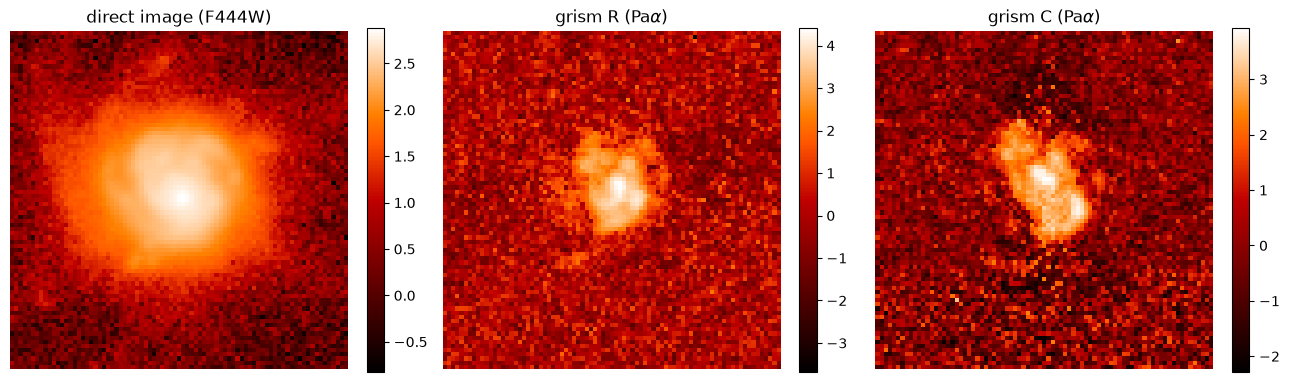

In [40]:
coadd_image = fits.getdata(f'ID{ID}/image.fits')
coadd_R     = fits.getdata(f'ID{ID}/R.fits')
coadd_C     = fits.getdata(f'ID{ID}/C.fits')
print(f'direct {coadd_image.shape}   R {coadd_R.shape}   C {coadd_C.shape}')

fig, axs = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, im, title in [(axs[0], coadd_image, 'direct image (F444W)'),
                      (axs[1], coadd_R,     'grism R (Pa$\\alpha$)'),
                      (axs[2], coadd_C,     'grism C (Pa$\\alpha$)')]:
    m = ax.imshow(asinhstretch(im), origin='lower')
    ax.set_title(title); ax.grid(False); ax.set_axis_off()
    fig.colorbar(m, ax=ax, fraction=0.046)
plt.tight_layout(); plt.gcf().savefig(out('data_cutouts.png'), dpi=130, bbox_inches='tight')
plt.tight_layout(); plt.show()

## Morphology from pysersic

The morphology fit runs before the kinematics: 40x40 cutout, webbPSF `DET_DIST`
cropped to 19x19, `sky_type='flat'`, `HybridRenderer`, and a core-excluded disk
mask (0.20--1.10 arcsec). Its posterior supplies the inclination used below.

`fitter.sample()` is not called: it dies in `PySersicResults._parse_injested_data` on
arviz >= 1.0 (`DataTree` has no `drop_vars`), *after* sampling. The NUTS call below is
what it runs internally.

ID 15665  RA 64.00784  Dec -24.14891  zspec 1.1613
cutout (40, 40) at 0.0300 arcsec/pix


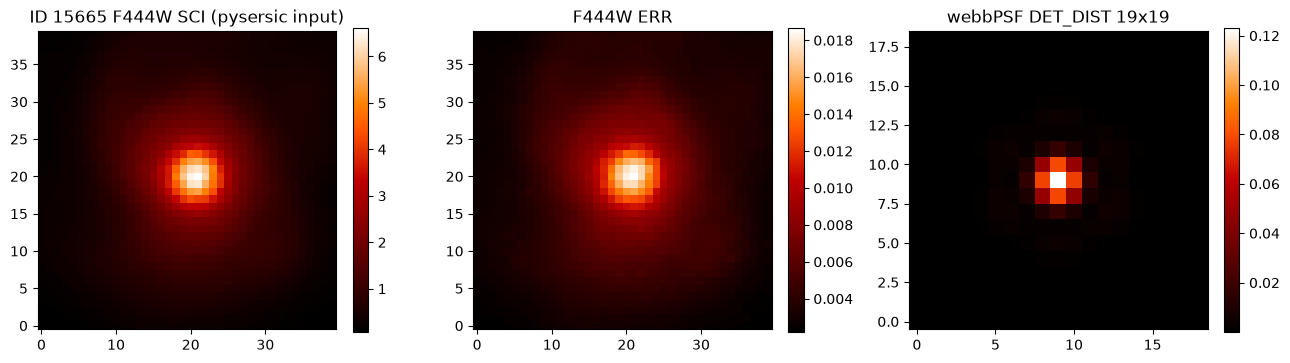

In [41]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from astropy.coordinates import SkyCoord

import jax
jax.config.update('jax_enable_x64', True)
from numpyro import infer
from pysersic.priors import SourceProperties
from pysersic import FitSingle
from pysersic.loss import gaussian_loss
from pysersic.rendering import HybridRenderer

# RA/Dec/z came from the catalogue, paths from the manifest cell
coord = SkyCoord(RA*u.deg, DEC*u.deg)
print(f'ID {ID}  RA {RA:.5f}  Dec {DEC:+.5f}  zspec {Z_CATALOG:.4f}')

with fits.open(MOSAIC_SCI) as h:
    mosaic_wcs = WCS(h[0].header)
    sci_cutout = Cutout2D(h[0].data, coord, CUTOUT_SIZE, wcs=mosaic_wcs)
with fits.open(MOSAIC_ERR) as h:
    err_cutout = Cutout2D(h[0].data, sci_cutout.input_position_original, CUTOUT_SIZE)
pixscale_mosaic = abs(mosaic_wcs.pixel_scale_matrix[0, 0])*3600
print(f'cutout {sci_cutout.data.shape} at {pixscale_mosaic:.4f} arcsec/pix')

with fits.open(PSF_FILE) as ph:
    try:
        psf_morph = ph['DET_DIST'].data.copy()
    except KeyError:
        psf_morph = ph[0].data.copy()
if psf_morph.shape[0] > 19:
    c = psf_morph.shape[0]//2
    psf_morph = psf_morph[c-9:c+10, c-9:c+10]
psf_morph = np.nan_to_num(psf_morph, nan=0.0, posinf=0.0, neginf=0.0)
psf_morph = psf_morph/psf_morph.sum()

fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
for a, im, t in [(ax[0], sci_cutout.data, f'ID {ID} {PYSERSIC_FILTER} SCI (pysersic input)'),
                 (ax[1], err_cutout.data, f'{PYSERSIC_FILTER} ERR'),
                 (ax[2], psf_morph,       'webbPSF DET_DIST 19x19')]:
    m = a.imshow(im, origin='lower', cmap='gist_heat'); a.set_title(t); a.grid(False)
    fig.colorbar(m, ax=a, fraction=0.046)
plt.tight_layout(); plt.gcf().savefig(out('pysersic_input.png'), dpi=130, bbox_inches='tight')
plt.tight_layout(); plt.show()

Prior for a sersic source:
--------------------------
flux ---  Normal w/ mu = 1001.81, sigma = 63.30
xc ---  Normal w/ mu = 19.50, sigma = 1.00
yc ---  Normal w/ mu = 19.50, sigma = 1.00
r_eff ---  Truncated Normal w/ mu = 9.83, sigma = 6.27, between: 0.50 -> inf
ellip ---  Uniform between: 0.00 -> 0.90
theta ---  Uniform between: 0.00 -> 6.28
n ---  Uniform between: 0.65 -> 8.00
sky type - flat
sky_back --- Normal with mu = 3.344e-01 and sd = 1.222e-02



sample: 100%|██████████| 1500/1500 [01:38<00:00, 15.27it/s, 767 steps of size 4.95e-04. acc. prob=0.93] 



                  mean       std    median      5.0%     95.0%     n_eff     r_hat
  ellip_base      0.17      0.00      0.17      0.17      0.17   1560.82      1.00
   flux_base      0.84      0.01      0.84      0.83      0.86   1920.16      1.00
      n_base      0.00      0.00      0.00      0.00      0.00    359.56      1.00
  r_eff_base     -0.12      0.00     -0.12     -0.12     -0.12   1914.25      1.00
    sky_back      0.10      0.00      0.10      0.10      0.10   1896.20      1.00
  theta_base      0.30      0.25      0.30      0.05      0.55      1.00   1870.30
     xc_base      0.83      0.00      0.83      0.83      0.83    619.79      1.00
     yc_base      0.70      0.00      0.70      0.70      0.71   1698.78      1.00

Number of divergences: 0

retrieve_param_quantiles([0.16, 0.50, 0.84]):
            0.16       0.50       0.84
ellip   0.149921   0.150135   0.150333
n       0.650002   0.650007   0.650017
r_eff   9.093453   9.097253   9.101294
theta   0.283889   1.85

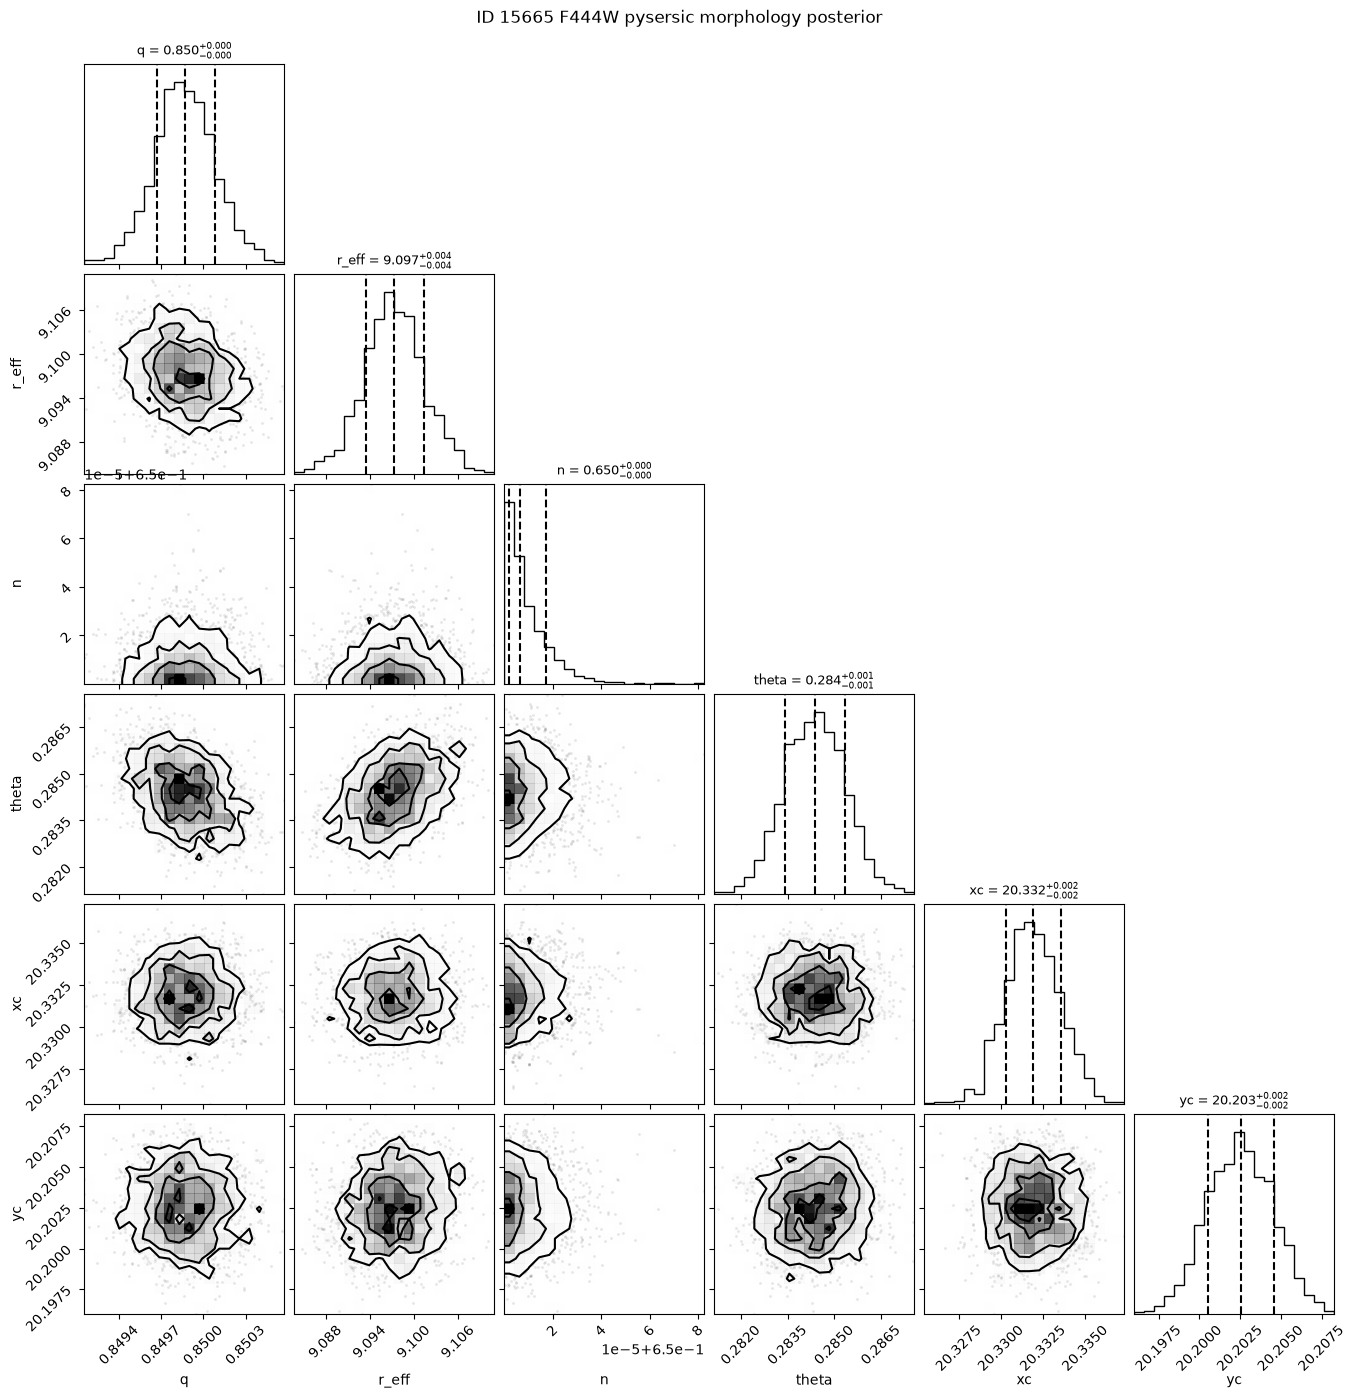

saved -> /Users/aakavan/Astro_Research/Galaxy_Kinematics/DINGO_development/grism-kinematics/results/ID15665/ID15665_sersic_F444W_pysersic_fixedinc.npz


In [42]:
PYSERSIC_RESULT_FILE = out(f'sersic_{PYSERSIC_FILTER}_pysersic_fixedinc.npz')
PYSERSIC_CORE_ARCSEC = 0.20
PYSERSIC_OUTER_ARCSEC = 1.10
METHOD_SCATTER = 0.0436  # morphology-method/systematic scatter in radians

if RUN_PYSERSIC:
    # The core is PSF-dominated and nearly round; excluding it is essential for
    # measuring the disk axis ratio rather than the central component.
    _yy, _xx = np.indices(sci_cutout.data.shape)
    _cx = (sci_cutout.data.shape[1] - 1) / 2.0
    _cy = (sci_cutout.data.shape[0] - 1) / 2.0
    _rr = np.hypot(_xx - _cx, _yy - _cy) * pixscale_mosaic
    _bad = ~np.isfinite(sci_cutout.data) | ~np.isfinite(err_cutout.data) | (err_cutout.data <= 0)
    _fit_mask = (_rr >= PYSERSIC_CORE_ARCSEC) & (_rr < PYSERSIC_OUTER_ARCSEC) & ~_bad
    _exclude = ~_fit_mask
    sp = SourceProperties(sci_cutout.data, mask=_exclude)
    sp.set_position_guess(position_guess=(CUTOUT_SIZE/2 - 0.5, CUTOUT_SIZE/2 - 0.5))
    prior = sp.generate_prior('sersic', sky_type='flat')
    print(prior)

    fitter = FitSingle(data=sci_cutout.data, rms=np.where(_bad, 1e10, err_cutout.data),
                       mask=_exclude, psf=psf_morph,
                       prior=prior, renderer=HybridRenderer, loss_func=gaussian_loss)

    # what fitter.sample() runs internally, minus the arviz post-processing it dies on
    # chain_method stays 'sequential': numpyro's 'parallel' path pmaps over devices and
    # raises "Vector and operator structures do not match" with this jax/numpyro pair.
    # N_CORES still applies -- it sets the intra-op thread count each chain uses.
    sampler = infer.MCMC(infer.NUTS(fitter.build_model(return_model=False),
                                    init_strategy=infer.init_to_sample),
                         num_chains=2, num_warmup=500, num_samples=1000,
                         chain_method='sequential')
    sampler.run(jax.random.PRNGKey(42))
    sampler.print_summary(exclude_deterministic=True)
    pysersic_post = sampler.get_samples()

    cols = ['ellip', 'n', 'r_eff', 'theta', 'xc', 'yc']
    q_table = pd.DataFrame(
        {p: [np.percentile(np.asarray(pysersic_post[c]).ravel(), 100*p) for c in cols]
         for p in (0.16, 0.50, 0.84)}, index=cols)
    print('\nretrieve_param_quantiles([0.16, 0.50, 0.84]):')
    print(q_table)

    q_samples = 1.0 - np.asarray(pysersic_post['ellip']).ravel()
    inc_samples = np.arccos(np.clip(q_samples, 0.0, 1.0))
    ql, qm, qh = np.percentile(q_samples, [16, 50, 84])
    il, im_, ih = np.percentile(inc_samples, [16, 50, 84])
    print(f'\naxis ratio   q = {qm:.4f} -{qm-ql:.4f} +{qh-qm:.4f}')
    print(f'inclination  i = {im_:.4f} -{im_-il:.4f} +{ih-im_:.4f} rad '
          f'({np.rad2deg(im_):.2f} deg)      [q = cos i, the geometry the velocity model assumes]')
    print(f'r_eff = {q_table.loc["r_eff", 0.50]:.2f} pix '
          f'= {q_table.loc["r_eff", 0.50]*pixscale_mosaic:.4f} arcsec,  '
          f'n = {q_table.loc["n", 0.50]:.3f}')

    print('\n--- inclination estimates on the table ---')
    print(f'{"method":<46}{"inc [rad]":>11}{"inc [deg]":>11}')
    for label, val in [('pysersic, no mask, 40x40 (this cell)', im_),
                       ('pysersic, core-masked (measure_inclination.py)', 0.5801),
                       ('emcee Sersic, core-masked', 0.5850),
                       ('elliptical annuli, F444W (mean)', 0.6338),
                       ('adopted prior for the MCMC run', 0.6412),
                       ('KINEMATIC fit, no inclination prior', 0.4380)]:
        print(f'{label:<46}{val:>11.4f}{np.rad2deg(val):>11.2f}')

    # corner plot of the morphology posterior
    import corner
    corner_cols = ['q', 'r_eff', 'n', 'theta', 'xc', 'yc']
    corner_data = np.column_stack([
        q_samples,
        np.asarray(pysersic_post['r_eff']).ravel(),
        np.asarray(pysersic_post['n']).ravel(),
        np.remainder(np.asarray(pysersic_post['theta']).ravel() + np.pi, np.pi),
        np.asarray(pysersic_post['xc']).ravel(),
        np.asarray(pysersic_post['yc']).ravel()])
    fig = corner.corner(corner_data, labels=corner_cols, show_titles=True,
                        title_fmt='.3f', quantiles=[0.16, 0.5, 0.84],
                        title_kwargs={'fontsize': 9}, label_kwargs={'fontsize': 10})
    fig.suptitle(f'ID {ID} {PYSERSIC_FILTER} pysersic morphology posterior', y=1.01)
    fig.savefig(out(f'sersic_{PYSERSIC_FILTER}_pysersic_corner.png'),
                dpi=120, bbox_inches='tight')
    plt.show()
    np.savez_compressed(PYSERSIC_RESULT_FILE,
                        **{c: np.asarray(pysersic_post[c]).ravel() for c in cols},
                        q=q_samples, inc=inc_samples)
    print('saved ->', PYSERSIC_RESULT_FILE)

    PYSERSIC_INC_SAMPLES = inc_samples
    PYSERSIC_INC, PYSERSIC_INC_SIG_FORMAL = float(im_), float(max(ih - im_, im_ - il))
elif os.path.exists(PYSERSIC_RESULT_FILE):
    with np.load(PYSERSIC_RESULT_FILE, allow_pickle=True) as _saved_ps:
        PYSERSIC_INC_SAMPLES = np.asarray(_saved_ps['inc'], dtype=float).ravel()
    _il, PYSERSIC_INC, _ih = np.percentile(PYSERSIC_INC_SAMPLES, [16, 50, 84])
    PYSERSIC_INC_SIG_FORMAL = float(max(PYSERSIC_INC - _il, _ih - PYSERSIC_INC))
    print('loaded pysersic result ->', PYSERSIC_RESULT_FILE)
else:
    PYSERSIC_INC_SAMPLES = None
    PYSERSIC_INC = PYSERSIC_INC_SIG_FORMAL = None
    print('RUN_PYSERSIC = False and no saved pysersic result -- cannot fix inclination')

In [43]:
# ===========================================================================
# Fixed inclination used by the kinematic fit
# ===========================================================================
# This is deliberately a standalone block: the value comes from the pysersic
# posterior produced immediately above, never from a hard-coded inclination.
if FIX_INCLINATION:
    if PYSERSIC_INC is None or PYSERSIC_INC_SAMPLES is None:
        raise RuntimeError('fixed inclination requires a pysersic posterior; '
                           'set RUN_PYSERSIC=True or provide the saved result')
    FIXED_INC_RAD = float(PYSERSIC_INC)
    FIXED_INC_SIGMA = float(max(PYSERSIC_INC_SIG_FORMAL, METHOD_SCATTER))
    print('ASSIGNED FIXED_INCLINATION')
    print(f'  source     = {PYSERSIC_RESULT_FILE}')
    print(f'  i          = {FIXED_INC_RAD:.6f} rad = {np.degrees(FIXED_INC_RAD):.3f} deg')
    print(f'  formal +/- = {PYSERSIC_INC_SIG_FORMAL:.6f} rad')
    print(f'  adopted +/-= {FIXED_INC_SIGMA:.6f} rad = {np.degrees(FIXED_INC_SIGMA):.3f} deg')
else:
    print('FIX_INCLINATION=False -- velocity.inc_v remains free')

ASSIGNED FIXED_INCLINATION
  source     = /Users/aakavan/Astro_Research/Galaxy_Kinematics/DINGO_development/grism-kinematics/results/ID15665/ID15665_sersic_F444W_pysersic_fixedinc.npz
  i          = 0.555067 rad = 31.803 deg
  formal +/- = 0.000406 rad
  adopted +/-= 0.043600 rad = 2.498 deg


### Two-component F444W morphology: compact component + disk

This independent fit measures the disk-light $R_{80}$. PySersic's `doublesersic` profile shares a centre and position angle: component 1 is initialized as compact/high-$n$ and component 2 as extended/low-$n$ (the disk). It does not modify the single-Sersic posterior or the kinematic inclination prior.

Run this cell after the F444W input-preparation cell above. It samples and saves its own posterior.

In [44]:
# if not RUN_PYSERSIC:
#     print('RUN_PYSERSIC = False -- skipping two-component morphology')
# else:
#     # Standalone two-component morphology fit. This does not alter the existing
#     # single-Sersic posterior or its inclination prior. Component 1 is initialized
#     # compact/high-n (bulge); component 2 is extended/low-n (disk). Both share a
#     # centre and position angle, avoiding a poorly constrained free-centre fit.
#     import numpy as np
#     import jax
#     from numpyro import infer
#     from scipy.special import gammaincinv
#     from pysersic.priors import SourceProperties
#     from pysersic import FitSingle
#     from pysersic.loss import gaussian_loss
#     from pysersic.rendering import HybridRenderer

#     required_inputs = ['sci_cutout', 'err_cutout', 'psf_morph', 'out', 'ID', 'CUTOUT_SIZE',
#                        'PYSERSIC_FILTER', 'KPC_PER_PIX', 'arcsec_per_pixel', 'pixscale_mosaic']
#     missing_inputs = [name for name in required_inputs if name not in globals()]
#     if missing_inputs:
#         raise RuntimeError('Run the F444W input-preparation cell above first; missing: ' +
#                            ', '.join(missing_inputs))

#     PYSERSIC_2COMP_FILE = out(f'sersic_{PYSERSIC_FILTER}_pysersic_2comp.npz')
#     double_cols = ['f_1', 'ellip_1', 'ellip_2', 'n_1', 'n_2',
#                    'r_eff_1', 'r_eff_2', 'theta', 'xc', 'yc']

#     sp_2comp = SourceProperties(sci_cutout.data)
#     sp_2comp.set_position_guess(position_guess=(CUTOUT_SIZE/2 - 0.5, CUTOUT_SIZE/2 - 0.5))
#     prior_2comp = sp_2comp.generate_prior('doublesersic', sky_type='flat')
#     print(prior_2comp)

#     fitter_2comp = FitSingle(data=sci_cutout.data, rms=err_cutout.data, psf=psf_morph,
#                               prior=prior_2comp, renderer=HybridRenderer,
#                               loss_func=gaussian_loss)
#     sampler_2comp = infer.MCMC(
#         infer.NUTS(fitter_2comp.build_model(return_model=False),
#                    init_strategy=infer.init_to_sample),
#         num_chains=2, num_warmup=500, num_samples=1000,
#         chain_method='sequential')
#     sampler_2comp.run(jax.random.PRNGKey(84))
#     sampler_2comp.print_summary(exclude_deterministic=True)
#     pysersic_2comp_post = sampler_2comp.get_samples()
#     np.savez_compressed(PYSERSIC_2COMP_FILE,
#                         **{c: np.asarray(pysersic_2comp_post[c]).ravel() for c in double_cols})
#     print('saved ->', PYSERSIC_2COMP_FILE)

#     if pysersic_2comp_post is not None:
#         # Component 2 is the disk under the priors above. Convert its posterior
#         # effective radius to R80 using the analytic Sersic enclosed-light relation.
#         disk_re_pix = np.asarray(pysersic_2comp_post['r_eff_2']).ravel()
#         disk_n = np.asarray(pysersic_2comp_post['n_2']).ravel()
#         b_n_disk = gammaincinv(2.0 * disk_n, 0.5)
#         disk_r80_pix = disk_re_pix * (gammaincinv(2.0 * disk_n, 0.8) / b_n_disk) ** disk_n
#         kpc_per_arcsec = KPC_PER_PIX / arcsec_per_pixel
#         disk_r80_kpc = disk_r80_pix * pixscale_mosaic * kpc_per_arcsec
#         r80_l, r80_m, r80_h = np.percentile(disk_r80_kpc, [16, 50, 84])
#         print(f'disk R80 = {r80_m:.2f} -{r80_m-r80_l:.2f} +{r80_h-r80_m:.2f} kpc')

#         import corner
#         corner_data_2comp = np.column_stack([
#             np.asarray(pysersic_2comp_post['f_1']).ravel(),
#             np.asarray(pysersic_2comp_post['r_eff_1']).ravel(),
#             np.asarray(pysersic_2comp_post['n_1']).ravel(),
#             disk_re_pix, disk_n, disk_r80_kpc])
#         fig = corner.corner(corner_data_2comp,
#                             labels=['bulge flux fraction', 'bulge $R_e$ [pix]', 'bulge $n$',
#                                     'disk $R_e$ [pix]', 'disk $n$', 'disk $R_{80}$ [kpc]'],
#                             show_titles=True, title_fmt='.3f', quantiles=[0.16, 0.5, 0.84],
#                             title_kwargs={'fontsize': 9}, label_kwargs={'fontsize': 10})
#         fig.suptitle(f'ID {ID} {PYSERSIC_FILTER}: two-component morphology posterior', y=1.01)
#         fig.savefig(out(f'sersic_{PYSERSIC_FILTER}_pysersic_2comp_corner.png'),
#                     dpi=120, bbox_inches='tight')
#         plt.show()

## Fit the rotation curve (Adam / LBFGS, the MAP)

In [45]:
kinematics_fitter = fitting.KinematicsFitter(config_path=CONFIG)

# In fixed-inclination mode, apply the photometric geometry before Adam runs.
# This makes both the MAP and the posterior conditional on the same inclination;
# it is important not to fit Adam at one inclination and freeze another only later.
if FIX_INCLINATION:
    for stage_cfg in kinematics_fitter.param_config_lists['velocity']:
        inc_cfg = stage_cfg['velocity.inc_v']
        with torch.no_grad():
            inc_cfg.tensor.data.fill_(FIXED_INC_RAD)
        inc_cfg.fit = False
    mc = kinematics_fitter.config.setdefault('mcmc', {})
    mc['checkpoint'] = os.path.join(OUTDIR, f'ID{ID}_chain_fixedinc_checkpoint.npz')
    mc['nwalkers'] = 24
    mc['nburn'] = 1000
    mc['nsteps'] = 5000
    mc.setdefault('priors', {}).pop('velocity.inc_v', None)
    print(f'fixed velocity.inc_v = {FIXED_INC_RAD:.4f} rad '
          f'({np.degrees(FIXED_INC_RAD):.2f} deg) before Adam/MCMC')

all_losses, all_lrs = kinematics_fitter.fit_all()

image_R, image_C, vz_R, vz_C = kinematics_fitter.get_fitting_results()
velocity_params, dispersion_params_R, dispersion_params_C = kinematics_fitter.get_params()
true_grism_R, true_grism_C = kinematics_fitter.get_true_images()

def print_params(title, params):
    print(f'\n[{title}]')
    for name, param in params.items():
        if isinstance(param, (numbers.Number, np.number)):
            print(f'{name:10s} = {param:.4f}')
        else:
            print(f'{name:10s} = {param}')

print_params('Velocity', velocity_params)
print_params('Dispersion R', dispersion_params_R)
print_params('Dispersion C', dispersion_params_C)

12:00:19 - WARNING - dingo.fitting - [KinematicsFitter] summary.r_fit is deprecated under (x,y) origin=(0,0). Prefer explicit cutouts/centers in the config.
12:00:19 - [KinematicsFitter] summary.r_fit is deprecated under (x,y) origin=(0,0). Prefer explicit cutouts/centers in the config.
12:00:19 - INFO - dingo.fitting - [KinematicsFitter] using coordinate unit = pix
12:00:19 - [KinematicsFitter] using coordinate unit = pix
12:00:19 - WARNING - dingo.fitting - [KinematicsFitter] image.R.cutout is missing; derived (-123, 24, 81, 81) from summary.r_fit=40. Prefer an explicit cutout.
12:00:19 - [KinematicsFitter] image.R.cutout is missing; derived (-123, 24, 81, 81) from summary.r_fit=40. Prefer an explicit cutout.
12:00:19 - WARNING - dingo.fitting - [KinematicsFitter] image.C.cutout is missing; derived (43, -74, 81, 81) from summary.r_fit=40. Prefer an explicit cutout.
12:00:19 - [KinematicsFitter] image.C.cutout is missing; derived (43, -74, 81, 81) from summary.r_fit=40. Prefer an expl

fixed velocity.inc_v = 0.5551 rad (31.80 deg) before Adam/MCMC


12:00:19 - INFO - dingo.fitting - Stage 1, Step 1, loss=0.651, lr=0.05000xy_iters=(17, 22)
12:00:19 - Stage 1, Step 1, loss=0.651, lr=0.05000xy_iters=(17, 22)
12:00:20 - INFO - dingo.fitting - Stage 1, Step 100, loss=0.10979, lr=0.05000xy_iters=(12, 6)
12:00:20 - Stage 1, Step 100, loss=0.10979, lr=0.05000xy_iters=(12, 6)
12:00:22 - INFO - dingo.fitting - Stage 1, Step 200, loss=0.10203, lr=0.05000xy_iters=(10, 6)
12:00:22 - Stage 1, Step 200, loss=0.10203, lr=0.05000xy_iters=(10, 6)
12:00:23 - INFO - dingo.fitting - Stage 1, Step 300, loss=0.10032, lr=0.05000xy_iters=(11, 6)
12:00:23 - Stage 1, Step 300, loss=0.10032, lr=0.05000xy_iters=(11, 6)
12:00:25 - INFO - dingo.fitting - Stage 1, Step 400, loss=0.099555, lr=0.05000xy_iters=(10, 6)
12:00:25 - Stage 1, Step 400, loss=0.099555, lr=0.05000xy_iters=(10, 6)
12:00:26 - INFO - dingo.fitting - Stage 1, Step 500, loss=0.099129, lr=0.05000xy_iters=(8, 5)
12:00:26 - Stage 1, Step 500, loss=0.099129, lr=0.05000xy_iters=(8, 5)
12:00:28 - INF


[Velocity]
V_rot      = 459.0616455078125
R_v        = 3.3334078788757324
x0_v       = 42.39219284057617
y0_v       = 41.3027229309082
theta_v    = 2.332125663757324
inc_v      = 0.5550668239593506

[Dispersion R]
dx         = 0.9383692145347595
dy         = 0.23092420399188995
forward_model = <function get_grism_model_torch.<locals>.grism_inverse_model at 0x3b980a340>

[Dispersion C]
dx         = -0.15255431830883026
dy         = 0.9732155799865723
forward_model = <function get_grism_model_torch.<locals>.grism_inverse_model at 0x3807d3a60>


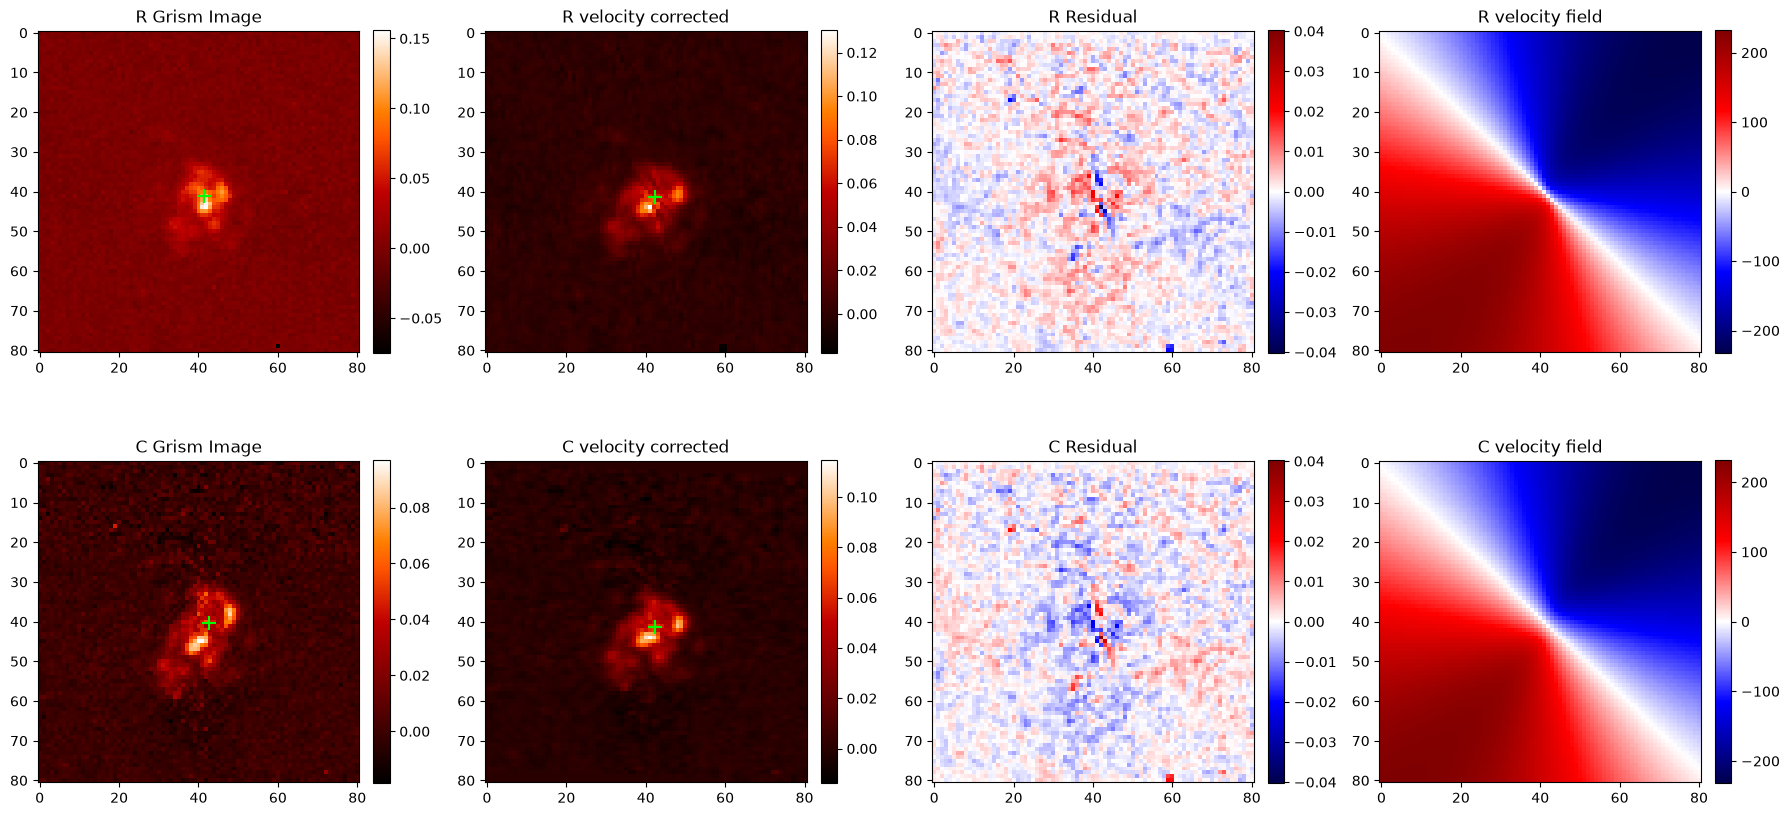

In [46]:
fig, axs = plt.subplots(2, 4, figsize=(18, 10))
plot.plot_kinematics_fitting_result(true_grism_R, image_R, vz_R, image_C, 'R',
                                    axs[0], velocity_params, dispersion_params_R)
plot.plot_kinematics_fitting_result(true_grism_C, image_C, vz_C, image_R, 'C',
                                    axs[1], velocity_params, dispersion_params_C)
plt.tight_layout(); plt.gcf().savefig(out('fit_panels_adam.png'), dpi=130, bbox_inches='tight')
plt.tight_layout(); plt.show()

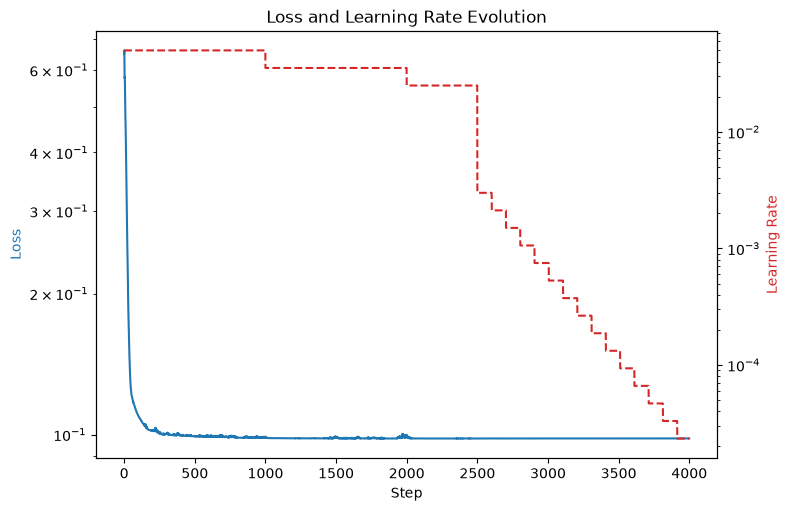

In [47]:
plot.plot_loss_and_lr(sum(all_losses, []), sum(all_lrs, []))

In [48]:
# Feed the measured morphology into the kinematics prior. q = cos(i) exactly in
# DINGO's convention: sersic_model_torch and arctangent_disk_velocity_model use the
# same deprojection, R = sqrt(x'^2 + (y'/q)^2).
#
# The formal pysersic error (~0.01 rad) is far too tight to use as a prior width --
# a single Sersic cannot describe this galaxy at ~1000 sigma per pixel, and the
# spread BETWEEN methods (Sersic vs elliptical annuli, F444W vs F200W) is what
# actually limits the measurement. Floor the width at the measured method scatter.
METHOD_SCATTER = 0.0436          # rad; see MCMC_STATUS.md for the eight estimates

if FIX_INCLINATION:
    print(f'fixed inclination for this run: i = {FIXED_INC_RAD:.4f} rad '
          f'({np.degrees(FIXED_INC_RAD):.2f} +- {np.degrees(FIXED_INC_SIGMA):.2f} deg)')
    print('the MCMC chain will not sample velocity.inc_v')
elif USE_PYSERSIC_PRIOR and PYSERSIC_INC is not None:
    sigma = max(PYSERSIC_INC_SIG_FORMAL, METHOD_SCATTER)
    kinematics_fitter.config.setdefault('mcmc', {}).setdefault('priors', {})
    old = kinematics_fitter.config['mcmc']['priors'].get('velocity.inc_v')
    kinematics_fitter.config['mcmc']['priors']['velocity.inc_v'] = {
        'type': 'gaussian', 'mu': PYSERSIC_INC, 'sigma': sigma,
        'min': 0.0873, 'max': 1.4835}
    print(f'inc_v prior <- pysersic: mu = {PYSERSIC_INC:.4f}, sigma = {sigma:.4f} rad '
          f'({np.rad2deg(PYSERSIC_INC):.2f} +- {np.rad2deg(sigma):.2f} deg)')
    print(f'  formal pysersic width {PYSERSIC_INC_SIG_FORMAL:.4f} -> floored at {METHOD_SCATTER}')
    print(f'  config value it replaces: {old}')
else:
    print('using the inc_v prior as written in the config:')
    print(' ', (kinematics_fitter.config.get('mcmc', {}).get('priors', {})
                .get('velocity.inc_v')))

fixed inclination for this run: i = 0.5551 rad (31.80 +- 2.50 deg)
the MCMC chain will not sample velocity.inc_v


## MCMC posterior

`fit_MCMC` samples the Adam-stage kinematic scalars using the same full-image R-minus-C SSE, with broad proper priors and Adam-centered walker initialization. There is no sampled `ln_f` in Adam-compatible mode.


In [49]:
# emcee's normal Pool path tries to pickle the bound fitter, which contains
# locally-created grism-model closures. On macOS, fork workers can inherit
# that fitted object directly, so this small adapter parallelizes only the
# theta evaluations and avoids serializing the fitter for every call.
_MCMC_WORKER_FITTER = None

def _mcmc_worker_init(fitter):
    global _MCMC_WORKER_FITTER
    _MCMC_WORKER_FITTER = fitter
    import torch as _torch
    _torch.set_num_threads(1)
    try:
        _torch.set_num_interop_threads(1)
    except RuntimeError:
        pass

def _mcmc_worker_log_probability(theta):
    return _MCMC_WORKER_FITTER.log_probability(theta)

class _EmceeProcessPool:
    def __init__(self, fitter, processes):
        self._fitter = fitter
        self._processes = int(processes)
        self._pool = None
    def _start(self):
        import multiprocessing as _mp
        if 'fork' not in _mp.get_all_start_methods():
            raise RuntimeError('fork start method is unavailable; use serial MCMC')
        # Start only after fit_MCMC has initialized _mcmc_priors and the
        # rest of the MCMC state on the fitter.
        self._pool = _mp.get_context('fork').Pool(
            processes=self._processes, initializer=_mcmc_worker_init,
            initargs=(self._fitter,))
    def map(self, _ignored_function, iterable):
        if self._pool is None:
            self._start()
        return self._pool.map(_mcmc_worker_log_probability, iterable)
    def close(self):
        if self._pool is not None:
            self._pool.close()
    def join(self):
        if self._pool is not None:
            self._pool.join()
    def terminate(self):
        if self._pool is not None:
            self._pool.terminate()

if RERUN_MCMC or RUN_MCMC or not os.path.exists(CHAIN):
    if RERUN_MCMC:
        # Start a clean run by removing only the active chain and its
        # resumable checkpoint. Set RERUN_MCMC=False to resume instead.
        _mcmc_paths = [CHAIN]
        _mc = kinematics_fitter.config.get('mcmc') or {}
        for _key in ('checkpoint', 'backend'):
            _path = _mc.get(_key)
            if _path:
                _path = os.path.abspath(os.path.expanduser(str(_path)))
                _mcmc_paths.append(_path)
                if _key == 'backend':
                    _mcmc_paths.append(_path + '.json')
        for _path in dict.fromkeys(_mcmc_paths):
            if os.path.exists(_path):
                os.remove(_path)
                print(f'removed {_path}')
    # fit_MCMC prepares the configured Adam-compatible likelihood.
    mcmc_pool = None
    if MCMC_USE_POOL:
        import torch as _torch
        _torch.set_num_threads(1)
        mcmc_pool = _EmceeProcessPool(kinematics_fitter, MCMC_PROCESSES)
        print(f'using {MCMC_PROCESSES} MCMC worker processes (1 torch thread each)')
    try:
        kinematics_fitter.fit_MCMC(pool=mcmc_pool)
    except BaseException:
        if mcmc_pool is not None:
            mcmc_pool.terminate()
            mcmc_pool.join()
        raise
    else:
        if mcmc_pool is not None:
            mcmc_pool.close()
            mcmc_pool.join()
    kinematics_fitter.save_mcmc(CHAIN)
    saved = np.load(CHAIN, allow_pickle=True)
else:
    saved = np.load(CHAIN, allow_pickle=True)
    print(f'loaded {CHAIN}')

chain  = saved['chain']                       # (nsteps, nwalkers, ndim)
names  = [str(s) for s in saved['param_names']]
nburn  = int(saved['nburn'])
flat   = chain[nburn:].reshape(-1, chain.shape[-1])
print(f'chain {chain.shape}, burn-in {nburn}, {flat.shape[0]} samples')
print(f'mean acceptance = {np.mean(saved["acceptance_fraction"]):.3f}')

post = {}
print(f'\n{"parameter":<20}{"median":>12}{"-1sigma":>10}{"+1sigma":>10}')
for j, n in enumerate(names):
    lo, med, hi = np.percentile(flat[:, j], [16, 50, 84])
    post[n] = med
    print(f'{n:<20}{med:>12.4f}{med-lo:>10.4f}{hi-med:>10.4f}')

loaded /Users/aakavan/Astro_Research/Galaxy_Kinematics/DINGO_development/grism-kinematics/results/ID15665/ID15665_chain_fixedinc.npz
chain (6000, 24, 9), burn-in 1000, 120000 samples
mean acceptance = 0.188

parameter                 median   -1sigma   +1sigma
velocity.V_rot          458.9093    3.6746    3.8180
velocity.R_v              3.3601    0.0750    0.0748
velocity.x0_v            42.5364    0.0979    0.0959
velocity.y0_v            41.5448    0.1536    0.1030
velocity.theta_v          2.3177    0.0097    0.0103
image.R.dx                0.9394    0.0204    0.0213
image.R.dy                0.2303    0.0137    0.0137
image.C.dx               -0.1500    0.0131    0.0129
image.C.dy                0.9701    0.0184    0.0177


### Convergence

`tau` is the integrated autocorrelation time -- how many steps the chain takes to forget
where it was. `n_steps/tau` is the number of effectively independent samples per walker,
and it is the number that decides whether a posterior width can be believed:
**want > 50**.

No R-hat: emcee is an *ensemble* sampler, so walkers propose from one another and are not
independent chains. Gelman-Rubin is optimistic by construction here and would give false
reassurance.

In [50]:
if 'kinematics_fitter' in dir() and getattr(kinematics_fitter, 'mcmc_sampler', None):
    d = kinematics_fitter.get_mcmc_diagnostics()
    print(f"steps {d['n_steps']} after {d['n_burn']} burn   "
          f"acceptance {d['acceptance_fraction'][0]:.3f} "
          f"(min {d['acceptance_fraction'][1]:.2f}, max {d['acceptance_fraction'][2]:.2f})")
    print(f"fraction of -inf evaluations: {d['frac_neg_inf']:.4f}\n")
    hdr = f'{"parameter":<20}{"tau":>9}{"n/tau":>9}{"split shift":>13}  flag'
    print(hdr); print('-'*len(hdr))
    for n in kinematics_fitter.mcmc_param_names:
        ntau = d['n_steps_over_tau'][n]
        flags = []
        if not (ntau > 50): flags.append('n/tau<50')
        if d['split_half_shift'][n] > 0.2: flags.append('drifting')
        print(f'{n:<20}{d["tau"][n]:>9.1f}{ntau:>9.1f}'
              f'{d["split_half_shift"][n]:>13.3f}  {", ".join(flags)}')
    worst = min(d['n_steps_over_tau'].values())
    print(f'\nworst n_steps/tau = {worst:.1f} '
          f'({"OK" if worst > 50 else "SHORT -- run more steps before quoting widths"})')
else:
    print('no chain in memory -- set RUN_MCMC = True and run the sampling cell')

no chain in memory -- set RUN_MCMC = True and run the sampling cell


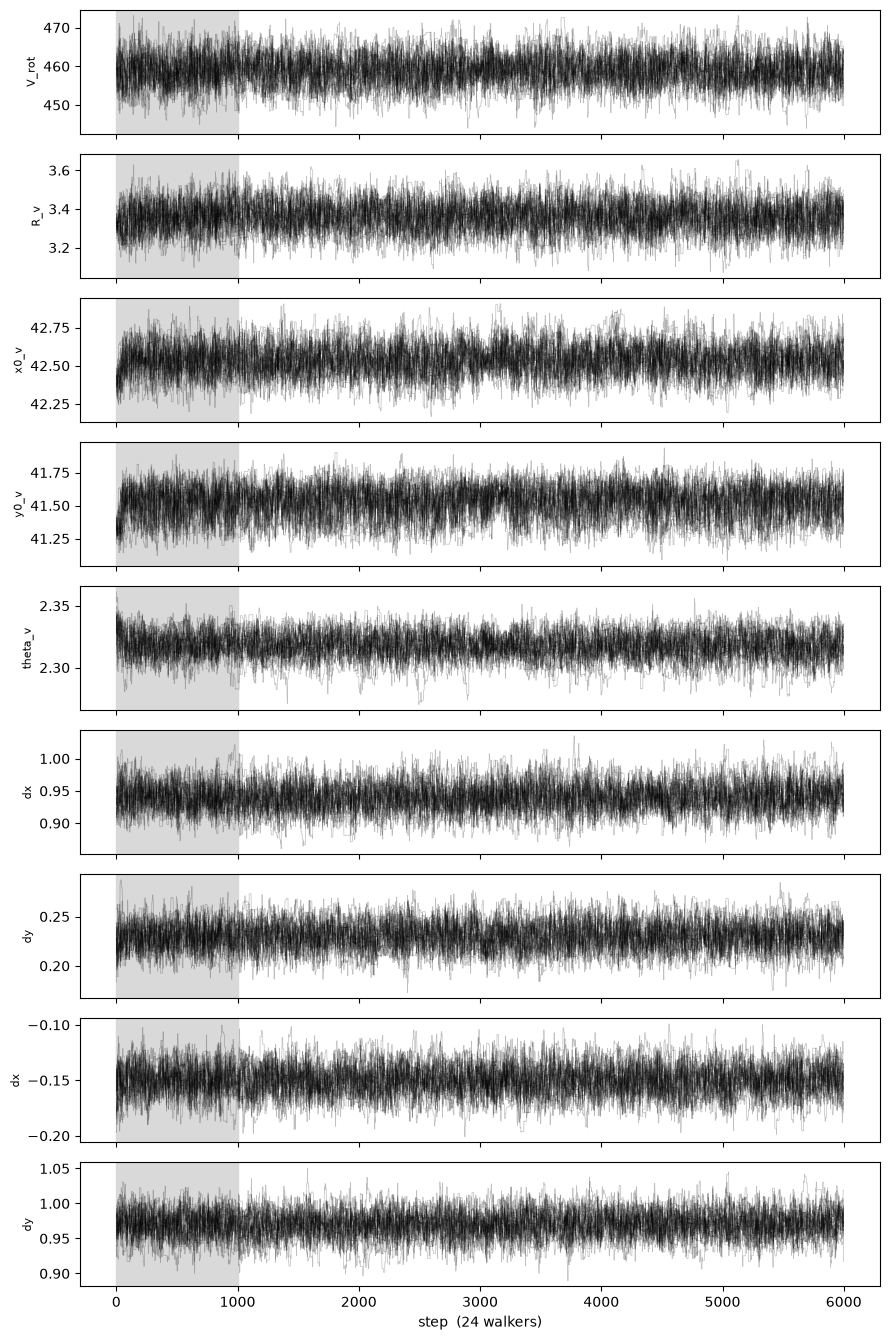

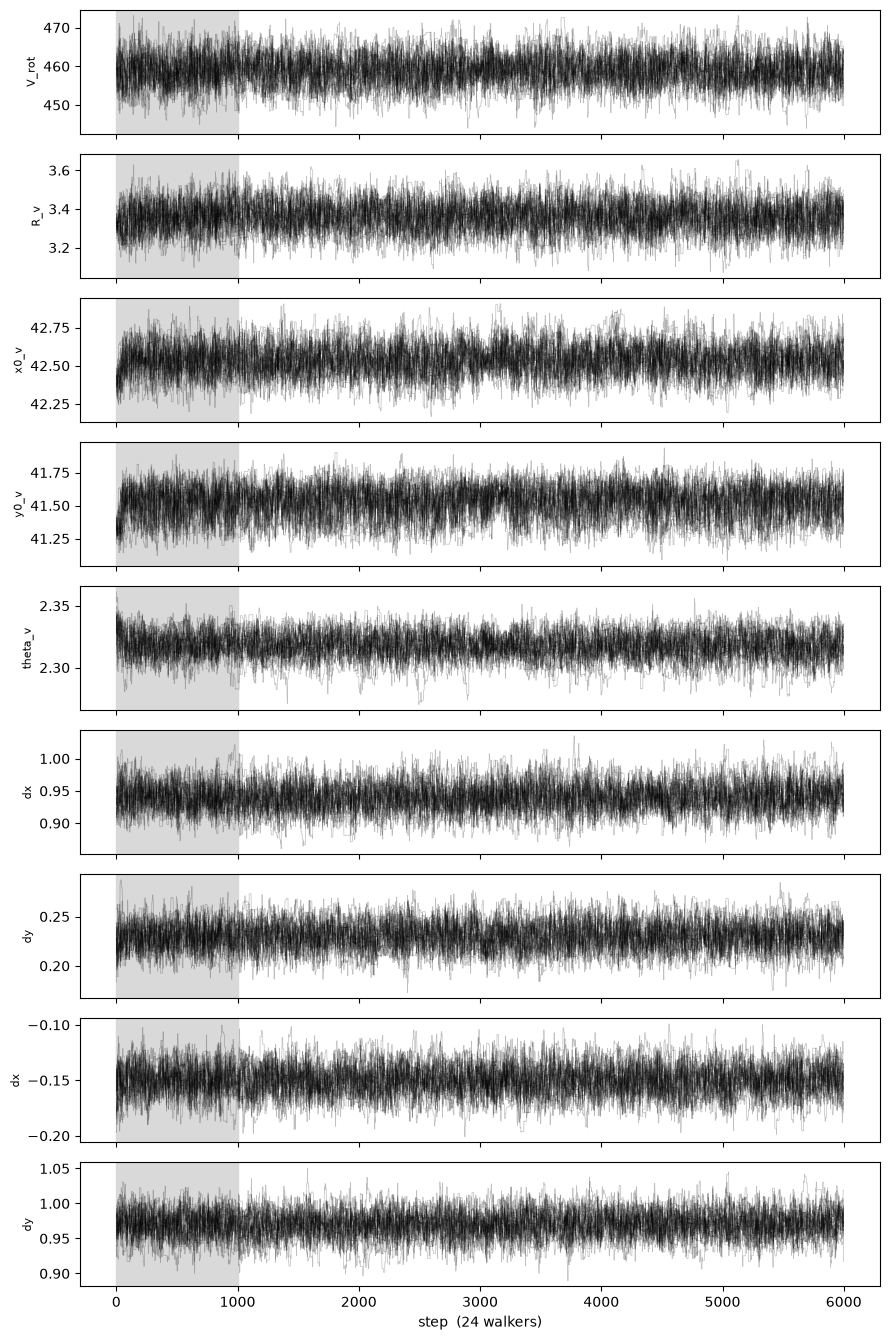

In [51]:
plot.plot_mcmc_chains(chain, names, nburn=nburn,
                      filename=out('mcmc_chains.png'))

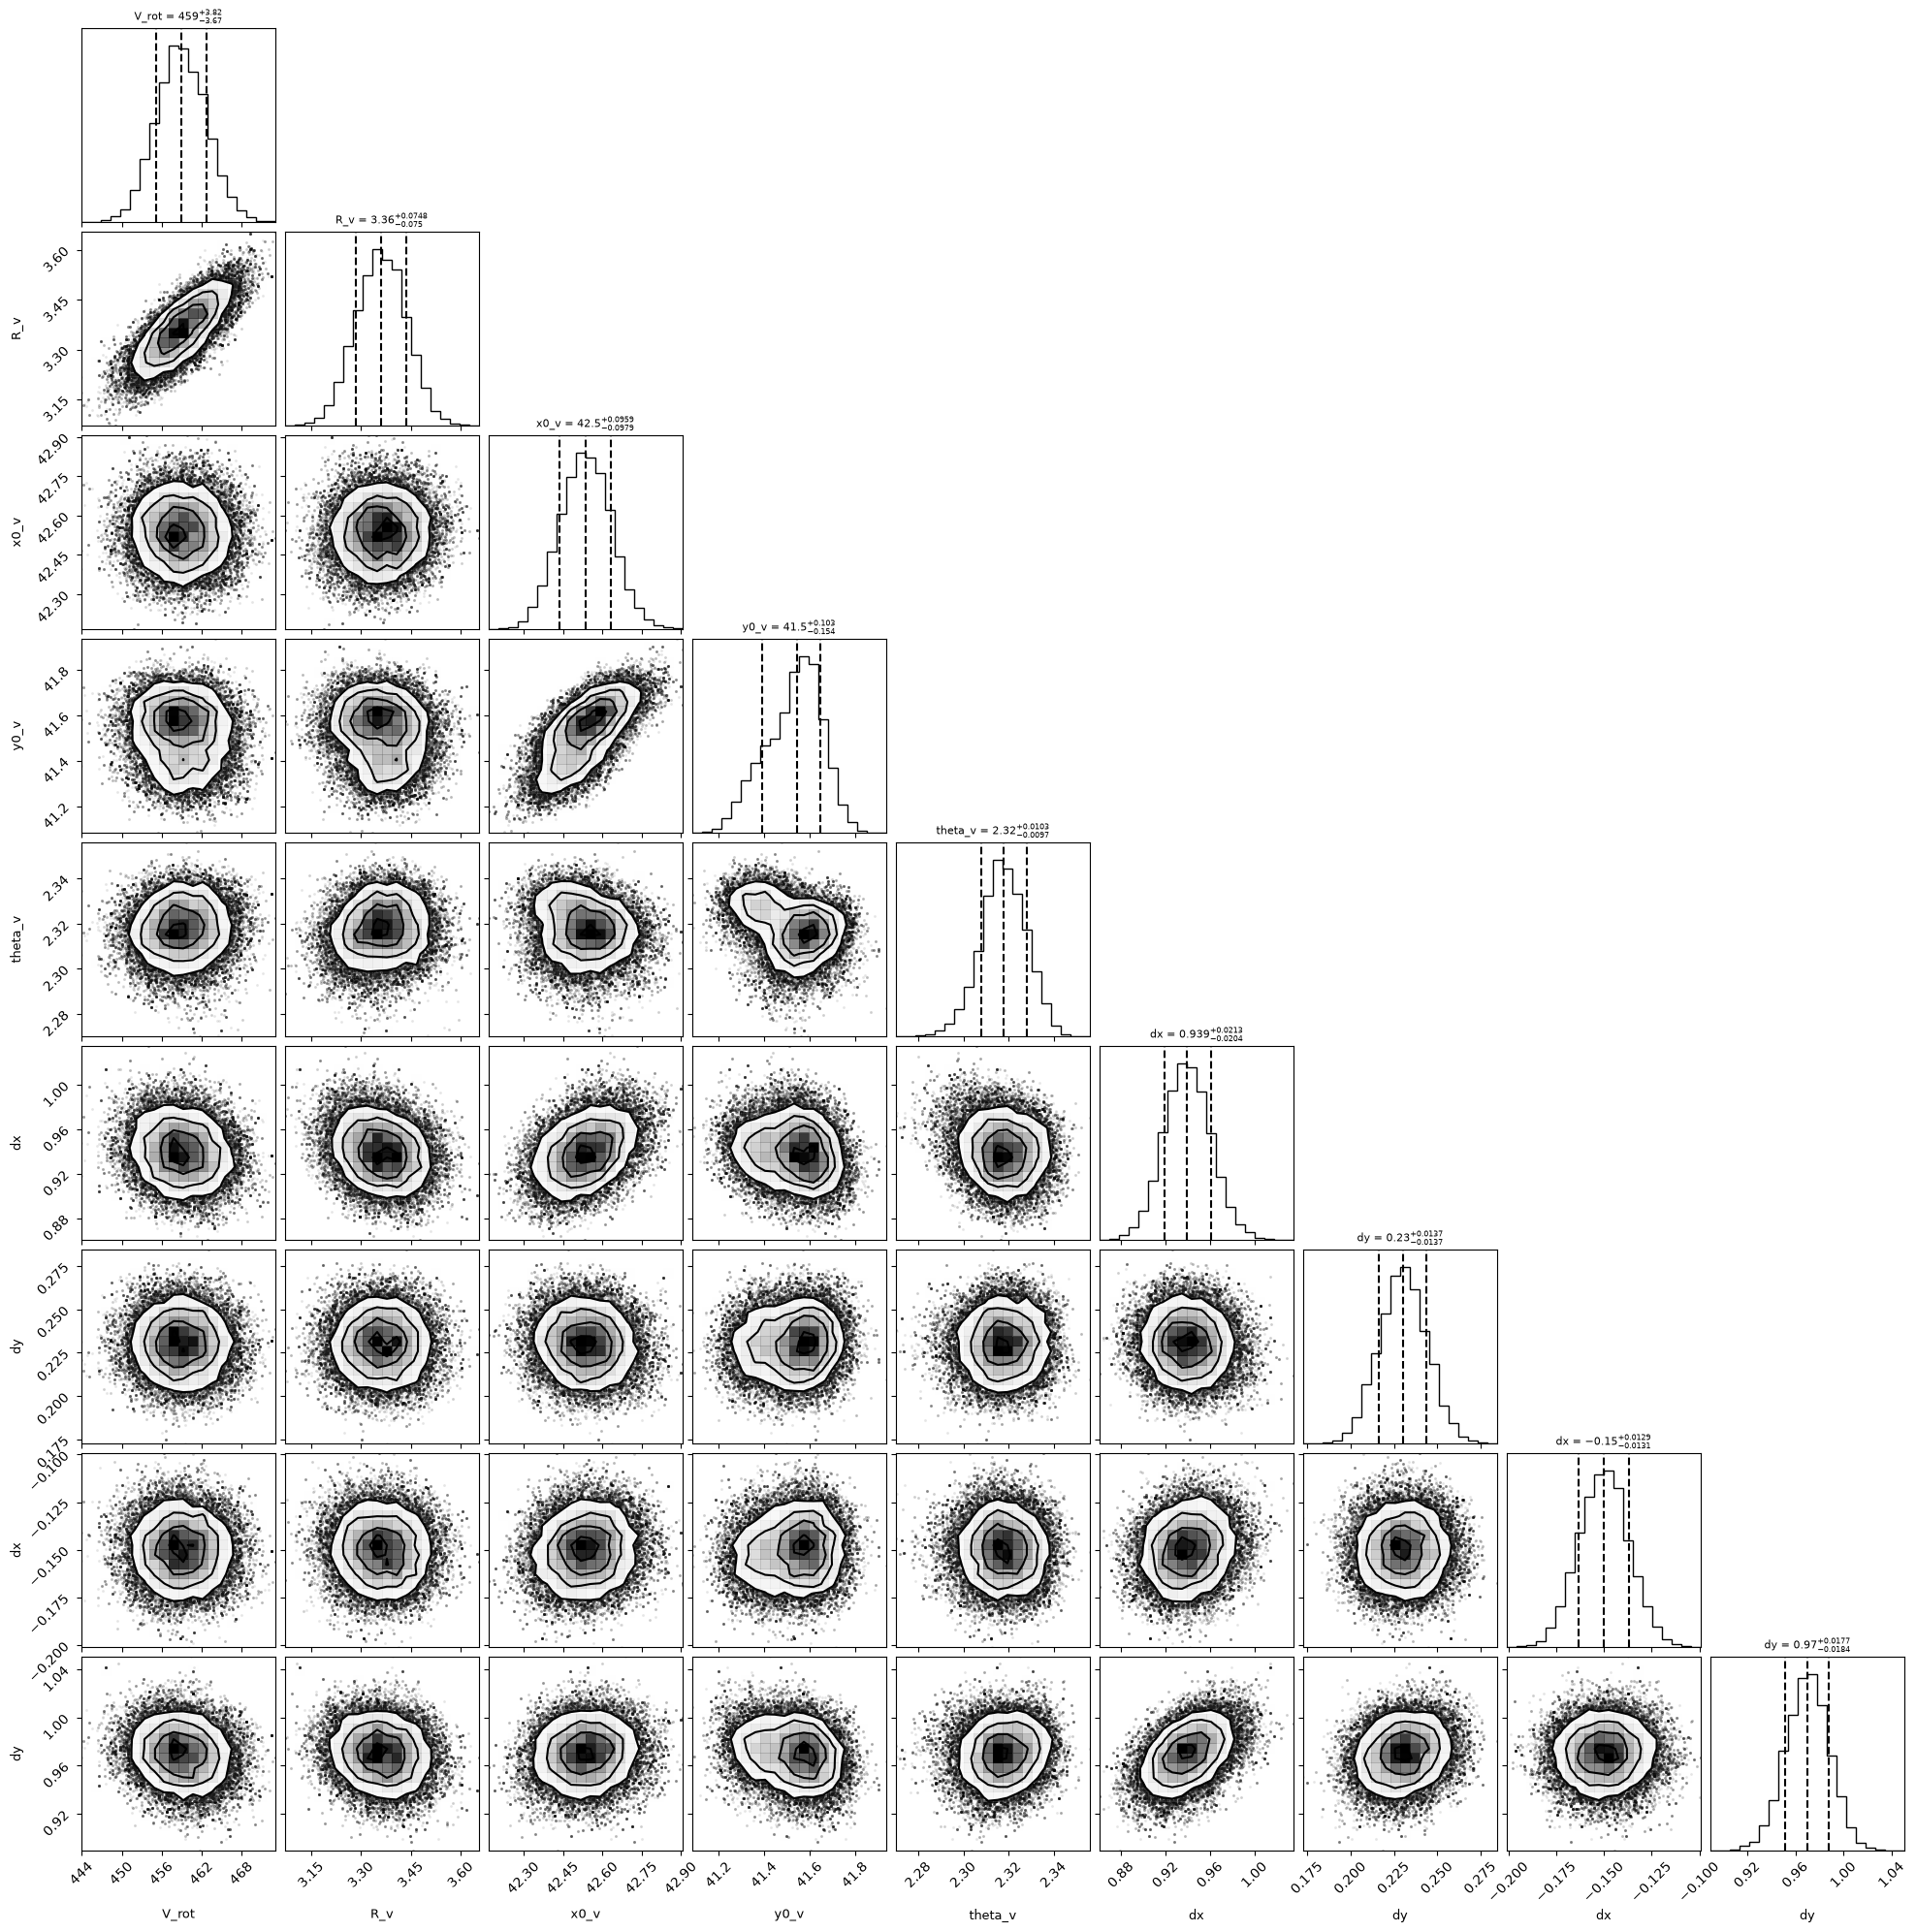

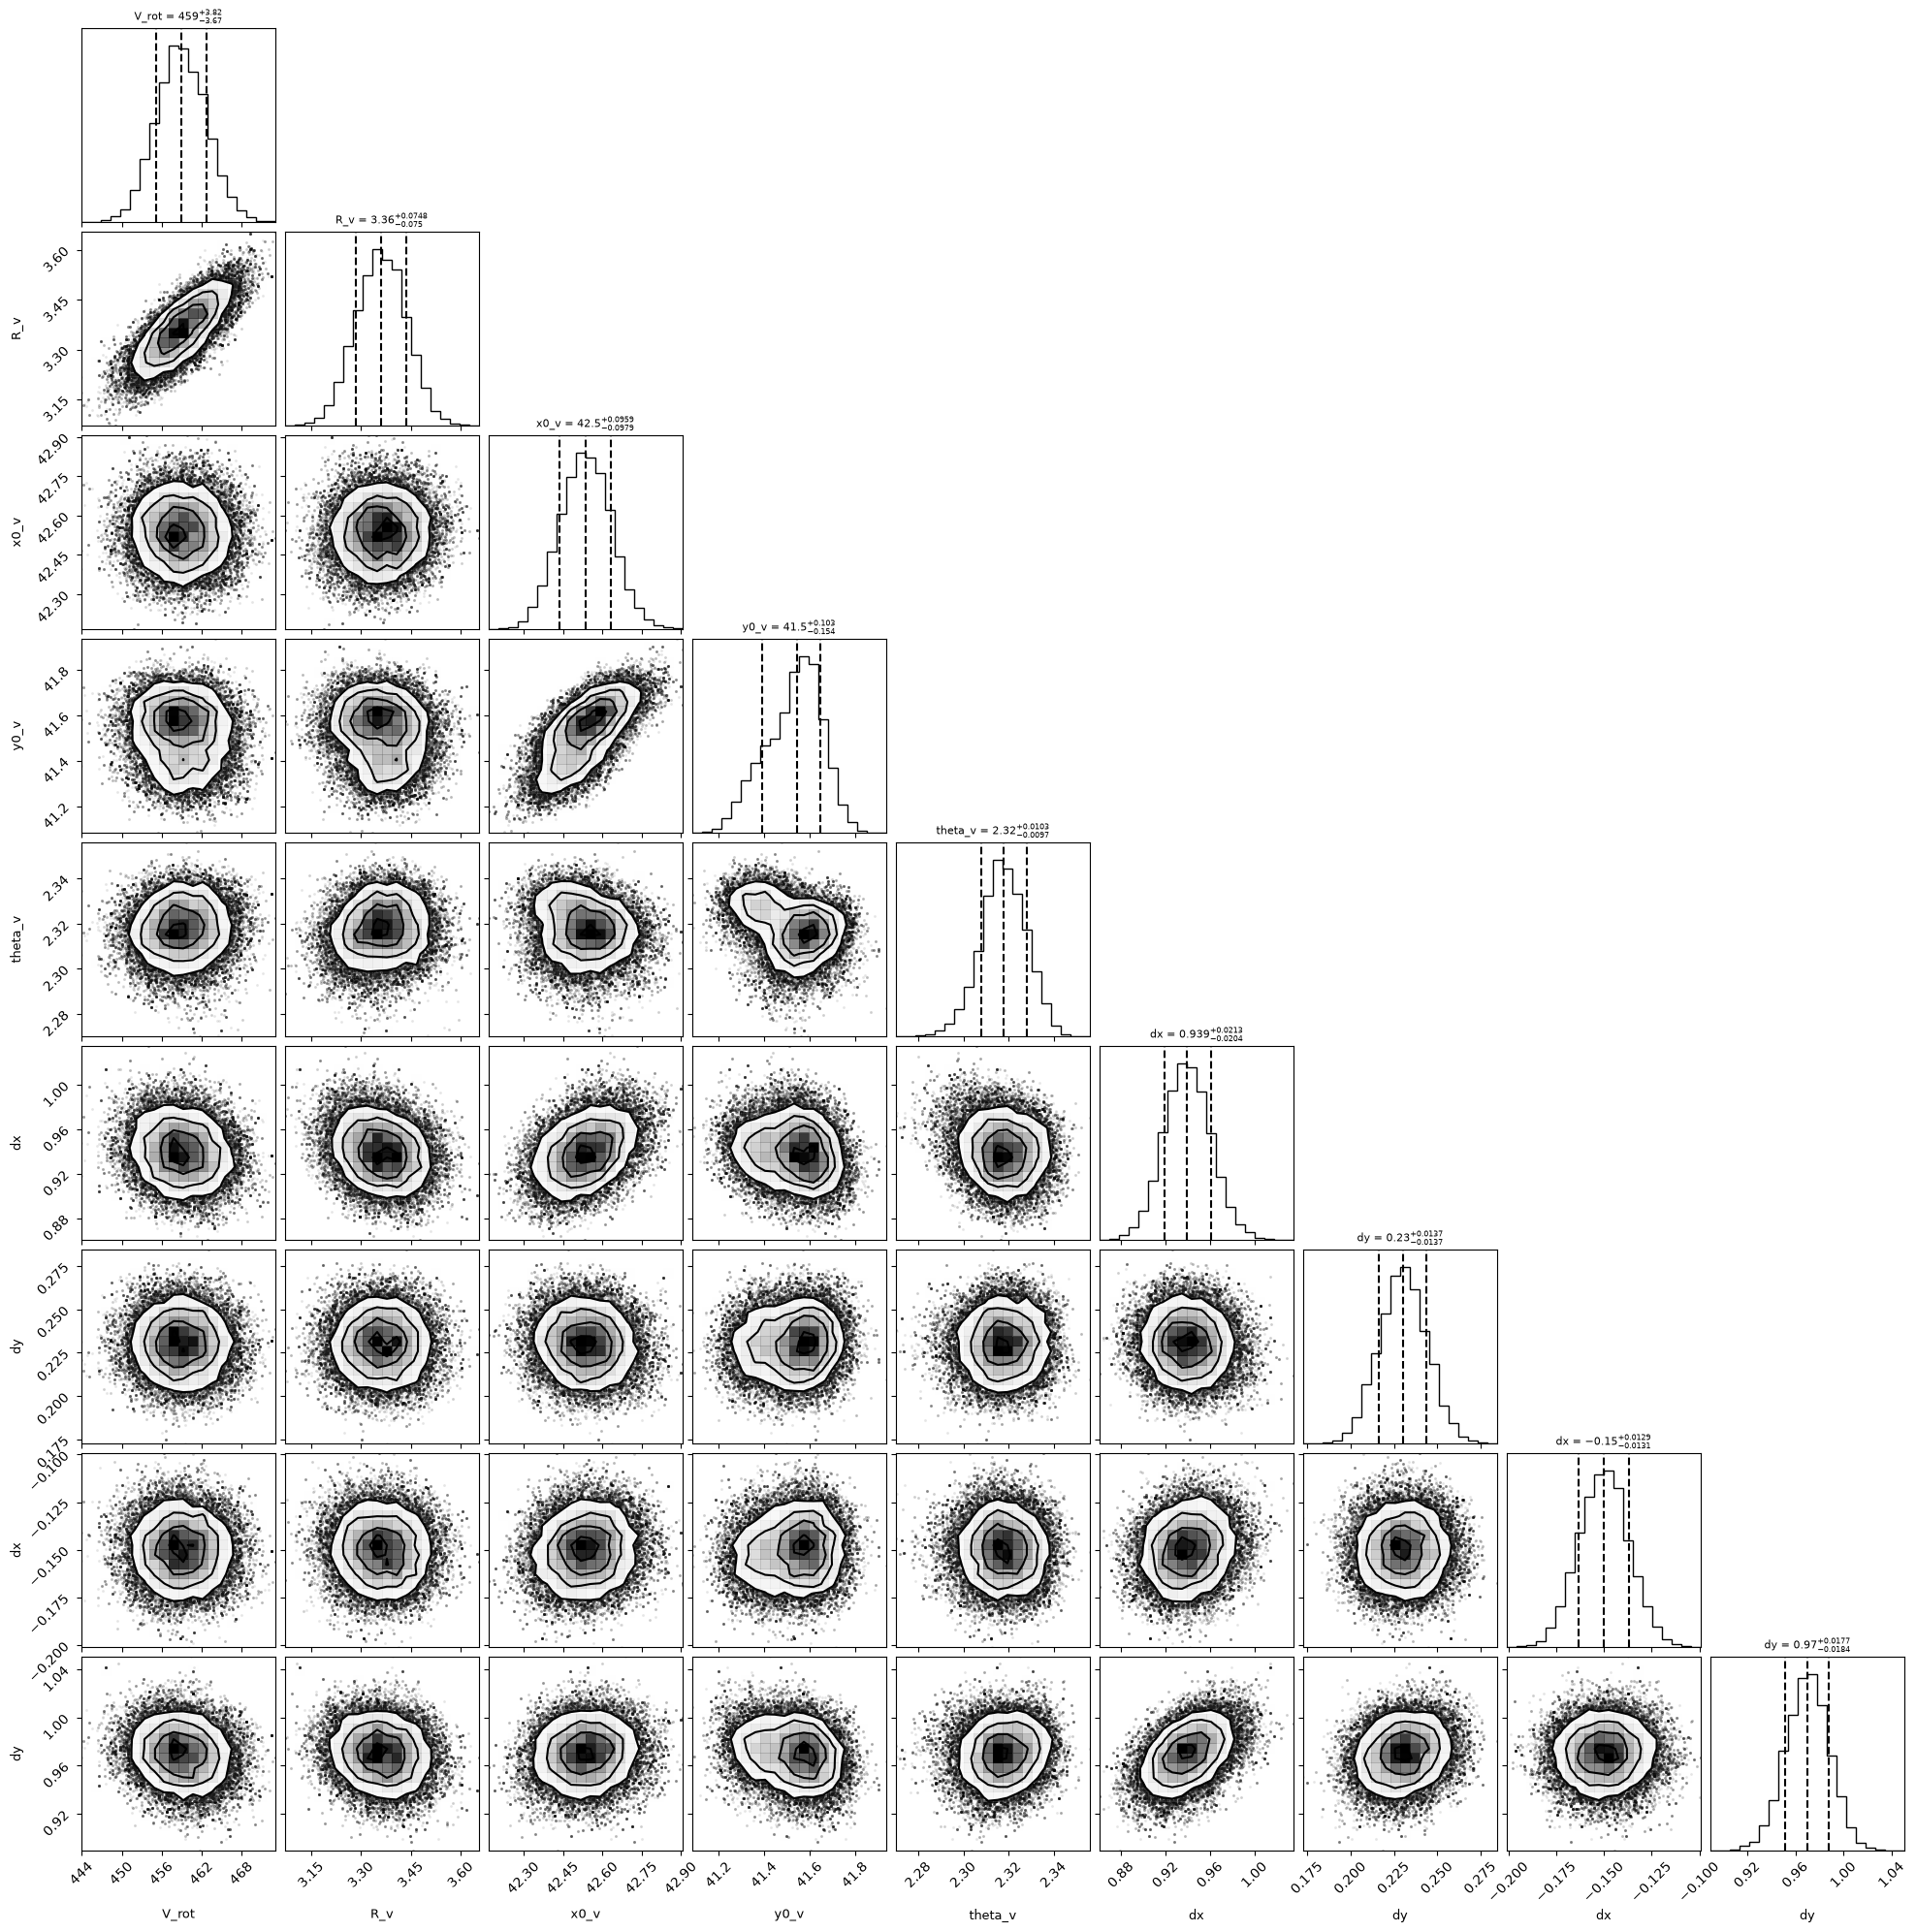

In [52]:
plot.plot_mcmc_corner(flat, names, filename=out('mcmc_corner.png'))

### Inclination handling

In fixed-inclination mode, `inc_v` is held at the adopted photometric value during
the kinematic fit. The grism constrains `V_rot * sin(i)`. The diagnostic below shows
both the narrow conditional `V_rot` posterior and the marginalized `V_rot` posterior,
where each `V sin(i)` draw is divided by an inclination draw from the PySersic
posterior plus the adopted method-to-method morphology scatter.

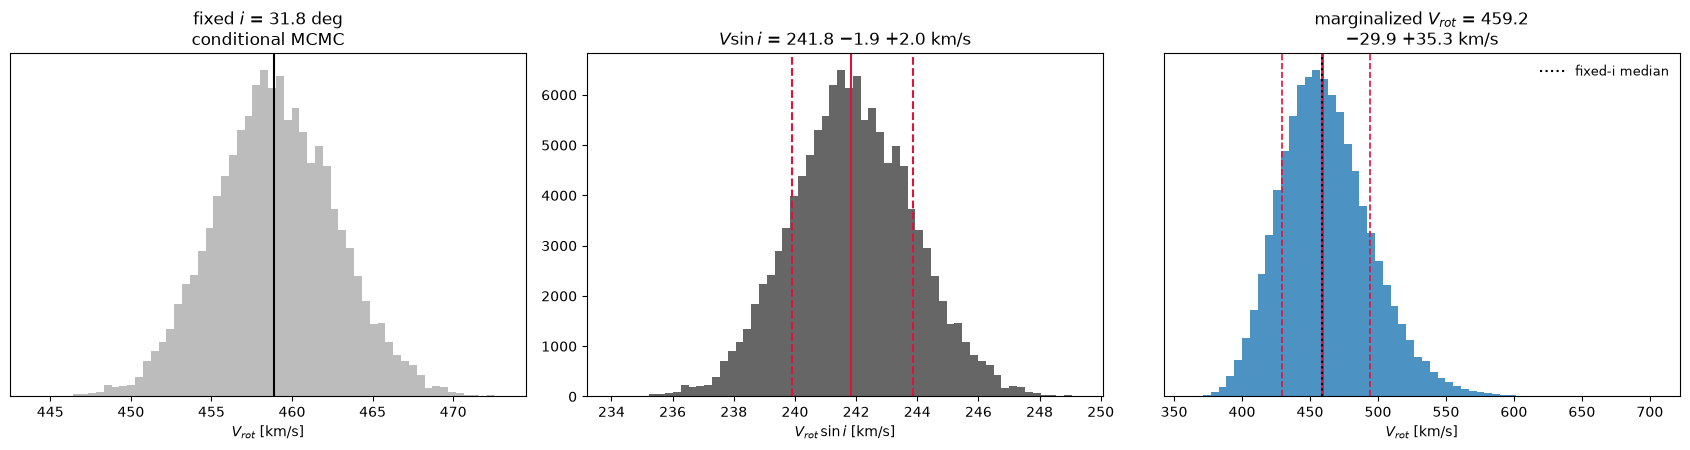

In [53]:
iV = names.index('velocity.V_rot')
V = flat[:, iV]
if 'velocity.inc_v' in names:
    iI = names.index('velocity.inc_v')
    inc = flat[:, iI]
else:
    iI = None
    inc = np.full_like(V, FIXED_INC_RAD)
Vsini = V*np.sin(inc)

# Draw the inclination uncertainty independently from the fixed-i chain.
# The chain supplies Vsini; the PySersic posterior supplies i. This is the
# same Monte Carlo propagation used for the headline result below.
if FIX_INCLINATION:
    _rng_plot = np.random.default_rng(15665)
    inc_marginal = _rng_plot.choice(PYSERSIC_INC_SAMPLES, size=Vsini.size, replace=True)
    inc_marginal = np.clip(inc_marginal + _rng_plot.normal(0.0, METHOD_SCATTER, Vsini.size),
                           0.0873, 1.4835)
    Vrot_marginal = Vsini/np.sin(inc_marginal)
else:
    inc_marginal = inc
    Vrot_marginal = V

fig, axs = plt.subplots(1, 3, figsize=(17, 4.6))
if iI is not None:
    axs[0].hexbin(V, inc, gridsize=60, cmap='gist_heat', mincnt=1)
    axs[0].set_xlabel('$V_{rot}$ [km/s]'); axs[0].set_ylabel('$i$ [rad]')
    axs[0].set_title(f'corr = {np.corrcoef(V, inc)[0,1]:+.3f}')
else:
    axs[0].hist(V, bins=60, color='0.65', alpha=0.75, label='conditional')
    axs[0].axvline(np.median(V), color='black', lw=1.5)
    axs[0].set_xlabel('$V_{rot}$ [km/s]'); axs[0].set_yticks([])
    axs[0].set_title(f'fixed $i$ = {np.degrees(FIXED_INC_RAD):.1f} deg\nconditional MCMC')

lo, med, hi = np.percentile(Vsini, [16, 50, 84])
axs[1].hist(Vsini, bins=60, color='0.4')
for v, ls in [(lo, '--'), (med, '-'), (hi, '--')]:
    axs[1].axvline(v, color='crimson', ls=ls)
axs[1].set_xlabel('$V_{rot}\\,\\sin i$ [km/s]')
axs[1].set_title(f'$V\\sin i$ = {med:.1f} $-${med-lo:.1f} $+${hi-med:.1f} km/s')
vlo_m, vmed_m, vhi_m = np.percentile(Vrot_marginal, [16, 50, 84])
axs[2].hist(Vrot_marginal, bins=60, color='tab:blue', alpha=0.80)
for vv, ls, lw in [(vlo_m, '--', 1.2), (vmed_m, '-', 2.0), (vhi_m, '--', 1.2)]:
    axs[2].axvline(vv, color='crimson', ls=ls, lw=lw)
axs[2].axvline(np.median(V), color='black', ls=':', lw=1.5,
                label='fixed-i median')
axs[2].set_xlabel('$V_{rot}$ [km/s]'); axs[2].set_yticks([])
axs[2].set_title(f'marginalized $V_{{rot}}$ = {vmed_m:.1f}\n'
                 f'$-${vmed_m-vlo_m:.1f} $+${vhi_m-vmed_m:.1f} km/s')
axs[2].legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.gcf().savefig(out('degeneracy_Vrot_inc.png'), dpi=130, bbox_inches='tight')
plt.gcf().savefig(out('Vrot_inclination_uncertainty.png'), dpi=180, bbox_inches='tight')
plt.tight_layout(); plt.show()

## Line-of-sight velocity field

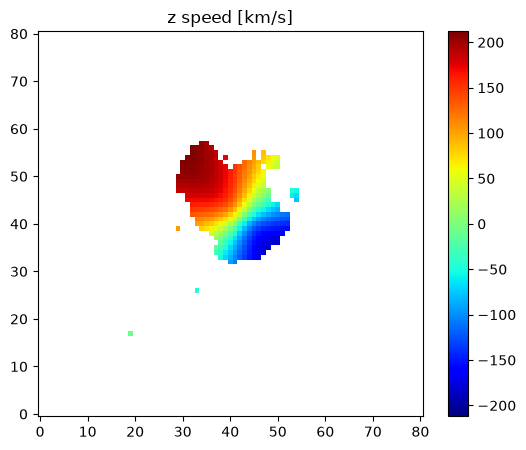

In [54]:
emline = np.average([image_R, image_C], axis=0)
_, _, std = sigma_clipped_stats(emline)
mask = emline > std*5
ny, nx = emline.shape
y, x = torch.meshgrid(torch.arange(ny), torch.arange(nx), indexing='ij')

def field(params, fn=kinematics.arctangent_disk_velocity_model):
    t = lambda k: torch.tensor(float(params[k]))
    return fn(x, y, t('V_rot'), t('R_v'), t('x0_v'), t('y0_v'),
              t('theta_v'), t('inc_v')).detach().cpu().numpy()

vz_np = field(velocity_params)
vz_np[~mask] = np.nan
vmax = np.nanmax(np.abs(vz_np))

plt.figure(figsize=(5.6, 4.6))
plt.imshow(vz_np, cmap='jet', vmin=-vmax, vmax=vmax, origin='lower')
plt.grid(False); plt.colorbar(); plt.title('z speed [km/s]')
plt.tight_layout(); plt.gcf().savefig(out('velocity_field_los.png'), dpi=130, bbox_inches='tight')
plt.tight_layout(); plt.show()

## Intrinsic circular rotation speed

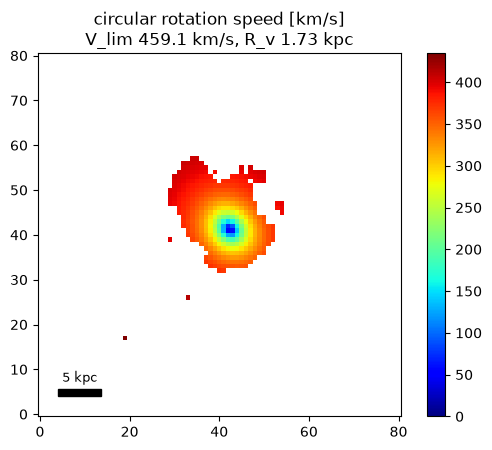

In [55]:
def arctangent_disk_rotation_speed(x, y, V_rot=200., R_v=2., x0_v=0., y0_v=0.,
                                   theta_v=0., inc_v=0., **kwargs):
    '''Intrinsic circular velocity field (not LOS-projected).'''
    dx, dy = x - x0_v, y - y0_v
    cos_t, sin_t = torch.cos(theta_v), torch.sin(theta_v)
    x_p = cos_t*dx + sin_t*dy
    y_p = -sin_t*dx + cos_t*dy
    r = torch.sqrt(x_p**2 + (y_p/torch.cos(inc_v))**2 + 1e-8)
    return (2/torch.pi)*V_rot*torch.atan(r/R_v)

vcirc = field(velocity_params, fn=arctangent_disk_rotation_speed)
vcirc[~mask] = np.nan

fig, ax = plt.subplots(figsize=(5.6, 4.6))
m = ax.imshow(vcirc, cmap='jet', vmin=0, vmax=np.nanmax(vcirc), origin='lower')

bar_kpc = 5
bar_pix = bar_kpc/KPC_PER_PIX
x0, y0 = nx*0.05, ny*0.05
ax.add_patch(patches.Rectangle((x0, y0), bar_pix, 1.5, color='black'))
ax.text(x0 + bar_pix/2, y0 + 2.5, f'{bar_kpc} kpc', color='black',
        ha='center', va='bottom', fontsize=9)

ax.grid(False); fig.colorbar(m, ax=ax)
ax.set_title(f'circular rotation speed [km/s]\n'
             f"V_lim {velocity_params['V_rot']:.1f} km/s, "
             f"R_v {velocity_params['R_v']*KPC_PER_PIX:.2f} kpc")
plt.tight_layout(); plt.gcf().savefig(out('rotation_speed_circular.png'), dpi=130, bbox_inches='tight')
plt.tight_layout(); plt.show()

## Enclosed dynamical mass

The MAP curve is the black line; the shaded band is the 16-84 percentile of the
posterior, i.e. the error bar the MCMC actually buys us.

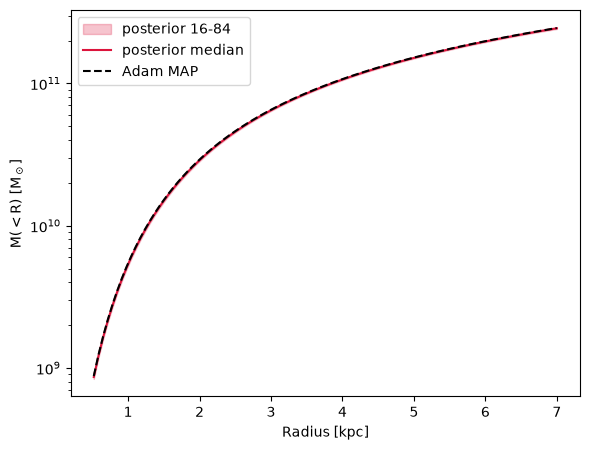

log10 M_dyn(<3 kpc) = 10.812 -0.005 +0.006
log10 M_dyn(<5 kpc) = 11.180 -0.005 +0.005


In [56]:
def arctangent_dynamical_mass(r_kpc, V_rot=200., R_v=2., **kwargs):
    '''M(<R) for the arctangent rotation curve, in M_sun.'''
    G = 4.302e-6                                   # kpc (km/s)^2 / M_sun
    V = (2/np.pi)*V_rot*np.arctan(r_kpc/R_v)
    return V**2*r_kpc/G

r_array = np.linspace(KPC_PER_PIX, 7, 100)

nsub = 2000
sub = np.random.default_rng(0).choice(flat.shape[0], nsub, replace=False)
iR = names.index('velocity.R_v')
curves = np.array([arctangent_dynamical_mass(r_array, flat[k, iV],
                                             flat[k, iR]*KPC_PER_PIX) for k in sub])
lo, med, hi = np.percentile(curves, [16, 50, 84], axis=0)

map_curve = arctangent_dynamical_mass(r_array, velocity_params['V_rot'],
                                      velocity_params['R_v']*KPC_PER_PIX)

plt.figure(figsize=(6, 4.6))
plt.fill_between(r_array, lo, hi, color='crimson', alpha=0.25, label='posterior 16-84')
plt.plot(r_array, med, color='crimson', label='posterior median')
plt.plot(r_array, map_curve, color='black', ls='--', label='Adam MAP')
plt.xlabel('Radius [kpc]'); plt.ylabel(r'M($<$R) [M$_\odot$]')
plt.yscale('log'); plt.legend(frameon=True); plt.grid(False)
plt.tight_layout(); plt.gcf().savefig(out('mass_profile.png'), dpi=130, bbox_inches='tight')
plt.tight_layout(); plt.show()

for r in [3.0, 5.0]:
    m = arctangent_dynamical_mass(r, flat[:, iV], flat[:, iR]*KPC_PER_PIX)
    a, b, c = np.percentile(np.log10(m), [16, 50, 84])
    print(f'log10 M_dyn(<{r:.0f} kpc) = {b:.3f} -{b-a:.3f} +{c-b:.3f}')

## Emission-line contours over the direct image

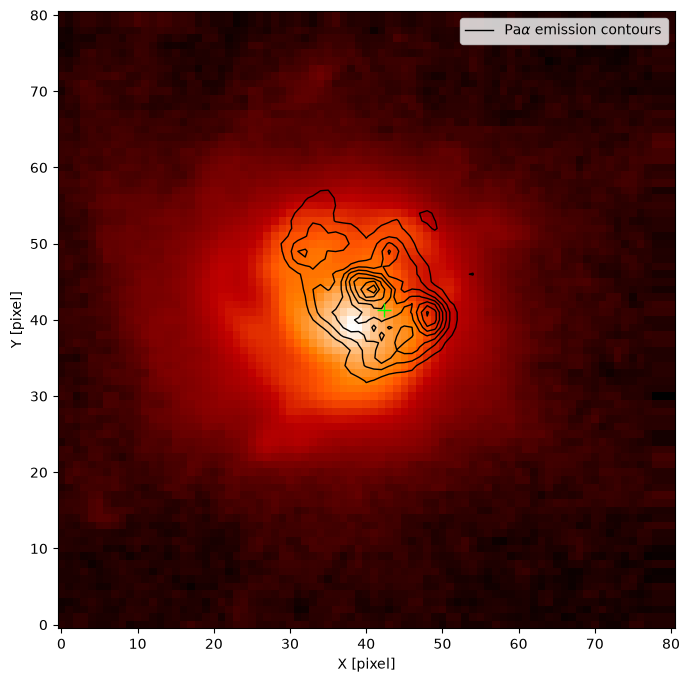

In [57]:
center_emission = (velocity_params['x0_v'], velocity_params['y0_v'])
center_direct   = (coadd_image.shape[1]//2, coadd_image.shape[0]//2)

direct_shifted = scipy.ndimage.shift(
    coadd_image,
    shift=(-(center_emission[1] - center_direct[1]),
           -(center_emission[0] - center_direct[0])),
    order=1, mode='nearest')

em_max = np.nanmax(emline)
levels = np.linspace(0.1*em_max, em_max, 9)

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(direct_shifted, cmap='gist_heat', origin='lower')
ax.contour(emline, levels=levels, colors='black', linewidths=1)
ax.plot(*center_emission, marker='+', color='lime', markersize=10, markeredgewidth=1)
ax.grid(False); ax.set_aspect('equal')
ax.set_xlabel('X [pixel]'); ax.set_ylabel('Y [pixel]')
ax.legend(handles=[Line2D([0], [0], color='black', lw=1,
                          label=r'Pa$\alpha$ emission contours')], frameon=True)
plt.tight_layout(); plt.gcf().savefig(out('emline_contours_on_direct.png'), dpi=130, bbox_inches='tight')
plt.tight_layout(); plt.show()

## Comparison: published Adam fit vs this MCMC

`NOTEBOOK_1_PARAMS` are the numbers printed by cell 17 of `1-fit-kinematics.ipynb`, read
off its stored output. The Adam refit here should reproduce them; the MCMC then says how
wide the posterior around them actually is.

In [58]:
# printed by cell 17 of 1-fit-kinematics.ipynb
NOTEBOOK_1_PARAMS = {
    'velocity.V_rot':   506.8591,
    'velocity.R_v':       3.3512,
    'velocity.x0_v':     42.5087,
    'velocity.y0_v':     41.5563,
    'velocity.theta_v':   2.3243,
    'velocity.inc_v':     0.5040,
    'image.R.dx':         0.6289,
    'image.R.dy':         0.4064,
    'image.C.dx':        -0.2692,
    'image.C.dy':        -0.3980,
}

def _f(v):
    '''get_params() hands back 0-d numpy arrays, which are not numbers.Number.'''
    try:
        return float(v)
    except (TypeError, ValueError):
        return None

adam = {f'velocity.{k}': _f(v) for k, v in velocity_params.items()}
adam = {k: v for k, v in adam.items() if v is not None}
adam.update({'image.R.dx': _f(dispersion_params_R['dx']),
             'image.R.dy': _f(dispersion_params_R['dy']),
             'image.C.dx': _f(dispersion_params_C['dx']),
             'image.C.dy': _f(dispersion_params_C['dy'])})

# (V_rot, theta_v) and (-V_rot, theta_v + pi) give an IDENTICAL velocity field, so a
# fit that starts at negative V_rot (make_config seeds V_rot = 300*sign, and this
# source's rotation sense is -1) converges to the mirrored copy of the same solution.
# fit_MCMC already reflects onto the positive branch; do the same here or the table
# subtracts two conventions and reports a nonsense difference.
if adam['velocity.V_rot'] < 0:
    adam['velocity.V_rot'] = -adam['velocity.V_rot']
    adam['velocity.theta_v'] = (adam['velocity.theta_v'] + np.pi) % (2*np.pi)
    print('note: Adam converged to the mirror solution (V_rot < 0); reflected onto the '
          'positive branch for comparison -- identical velocity field.\n')

hdr = (f'{"parameter":<18}{"notebook 1":>12}{"Adam here":>12}{"diff":>9}'
       f'{"MCMC median":>13}{"-1sig":>8}{"+1sig":>8}{"(MCMC-nb1)/sig":>16}')
print(hdr); print('-'*len(hdr))
for name, v1 in NOTEBOOK_1_PARAMS.items():
    va = adam.get(name, np.nan)
    if name not in names:
        print(f'{name:<18}{v1:>12.4f}{va:>12.4f}{va-v1:>9.4f}'
              f'{FIXED_INC_RAD:>13.4f}' + '{:>8}{:>8}{:>16}'.format('fixed', 'fixed', '--'))
        continue
    j = names.index(name)
    lo, med, hi = np.percentile(flat[:, j], [16, 50, 84])
    sig = 0.5*(hi - lo)
    print(f'{name:<18}{v1:>12.4f}{va:>12.4f}{va-v1:>9.4f}'
          f'{med:>13.4f}{med-lo:>8.4f}{hi-med:>8.4f}{(med-v1)/sig:>16.1f}')

_vel = [k for k in NOTEBOOK_1_PARAMS if k.startswith('velocity.')]
print(f'\nmax |Adam here - notebook 1|, velocity params only = '
      f'{max(abs(adam[k]-NOTEBOOK_1_PARAMS[k]) for k in _vel):.4f}')
print('The four image.* offsets are NOT comparable with notebook 1: correcting the')
print('redshift (1.123 -> 1.1613) moved the derived cutouts by ~73 px, so the sub-pixel')
print('registration between the grisms is a different quantity now.')
_vs_nb1 = NOTEBOOK_1_PARAMS['velocity.V_rot']*np.sin(NOTEBOOK_1_PARAMS['velocity.inc_v'])
_vs_ad  = adam['velocity.V_rot']*np.sin(FIXED_INC_RAD if FIX_INCLINATION
                                          else adam['velocity.inc_v'])
print(f'\nV*sin(i) is the quantity that should agree regardless of where the fit lands')
print(f'on the V_rot-inc_v ridge:  notebook 1 {_vs_nb1:.2f}   Adam here {_vs_ad:.2f} km/s')

parameter           notebook 1   Adam here     diff  MCMC median   -1sig   +1sig  (MCMC-nb1)/sig
------------------------------------------------------------------------------------------------
velocity.V_rot        506.8591    459.0616 -47.7975     458.9093  3.6746  3.8180           -12.8
velocity.R_v            3.3512      3.3334  -0.0178       3.3601  0.0750  0.0748             0.1
velocity.x0_v          42.5087     42.3922  -0.1165      42.5364  0.0979  0.0959             0.3
velocity.y0_v          41.5563     41.3027  -0.2536      41.5448  0.1536  0.1030            -0.1
velocity.theta_v        2.3243      2.3321   0.0078       2.3177  0.0097  0.0103            -0.7
velocity.inc_v          0.5040      0.5551   0.0511       0.5551   fixed   fixed              --
image.R.dx              0.6289      0.9384   0.3095       0.9394  0.0204  0.0213            14.9
image.R.dy              0.4064      0.2309  -0.1755       0.2303  0.0137  0.0137           -12.9
image.C.dx             -0.2692

quantity               from nb1 par  MCMC median    -1sig    +1sig
V sin(i) [km/s]            244.7785     241.8452   1.9365   2.0121
R_v [kpc]                    1.7421       1.7468   0.0390   0.0389
log10 M_dyn(<5kpc)          11.2665      11.1797   0.0045   0.0047


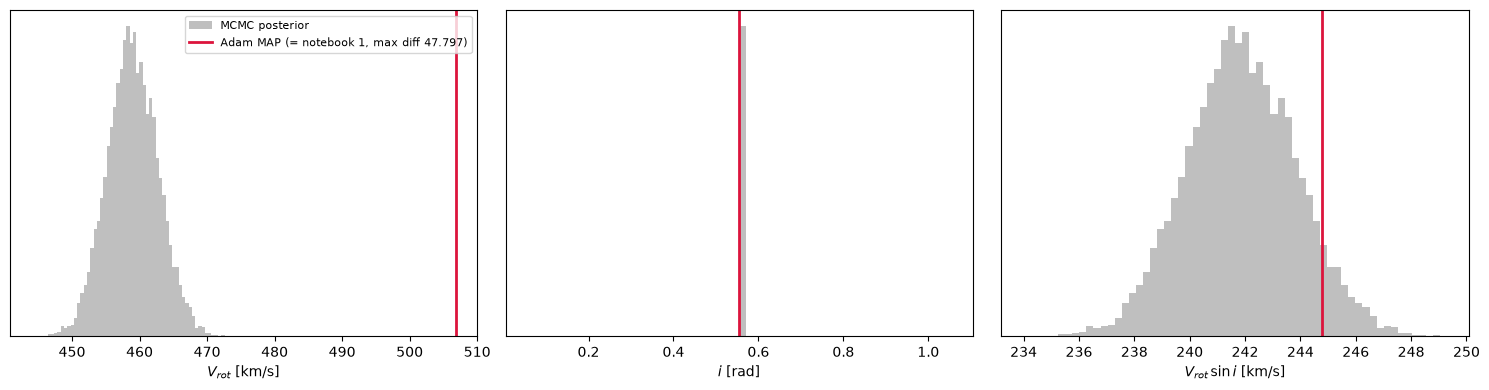

In [59]:
# Derived quantities. NOTE: 1-fit-kinematics.ipynb reports none of these except
# M_dyn -- V*sin(i) is computed here from its V_rot and inc_v, not read from it.
def derived(V_rot, R_v_pix, inc):
    return (V_rot*np.sin(inc), R_v_pix*KPC_PER_PIX,
            np.log10(arctangent_dynamical_mass(5.0, V_rot, R_v_pix*KPC_PER_PIX)))

d1 = derived(NOTEBOOK_1_PARAMS['velocity.V_rot'], NOTEBOOK_1_PARAMS['velocity.R_v'],
             NOTEBOOK_1_PARAMS['velocity.inc_v'])
inc_for_derived = flat[:, iI] if iI is not None else FIXED_INC_RAD
dm = derived(flat[:, iV], flat[:, iR], inc_for_derived)

print(f'{"quantity":<22}{"from nb1 par":>13}{"MCMC median":>13}{"-1sig":>9}{"+1sig":>9}')
for label, v1, s in [('V sin(i) [km/s]', d1[0], dm[0]),
                     ('R_v [kpc]',       d1[1], dm[1]),
                     ('log10 M_dyn(<5kpc)', d1[2], dm[2])]:
    lo, med, hi = np.percentile(s, [16, 50, 84])
    print(f'{label:<22}{v1:>13.4f}{med:>13.4f}{med-lo:>9.4f}{hi-med:>9.4f}')

# posterior vs the two point estimates
# One Adam line only: the refit here IS notebook 1's fit -- same config, same
# optimiser, agreeing to <0.1% (see the table above). Two lines would overplot.
_comparison_params = {k: v for k, v in NOTEBOOK_1_PARAMS.items()
                       if not (FIX_INCLINATION and k == 'velocity.inc_v')}
dmax = max(abs(adam[k] - v) for k, v in _comparison_params.items())
inc_reference = FIXED_INC_RAD if FIX_INCLINATION else NOTEBOOK_1_PARAMS['velocity.inc_v']
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, s_, v1, label in [
        (axs[0], flat[:, iV], NOTEBOOK_1_PARAMS['velocity.V_rot'], '$V_{rot}$ [km/s]'),
        (axs[1], inc_for_derived, inc_reference, '$i$ [rad]'),
        (axs[2], dm[0],       d1[0],                               r'$V_{rot}\,\sin i$ [km/s]')]:
    ax.hist(s_, bins=60, color='0.75', label='MCMC posterior')
    ax.axvline(v1, color='crimson', lw=2,
               label=f'Adam MAP (= notebook 1, max diff {dmax:.3f})')
    ax.set_xlabel(label); ax.set_yticks([]); ax.grid(False)
axs[0].legend(frameon=True, fontsize=8)
plt.tight_layout(); plt.gcf().savefig(out('compare_posterior_vs_adam.png'), dpi=130, bbox_inches='tight')
plt.tight_layout(); plt.show()

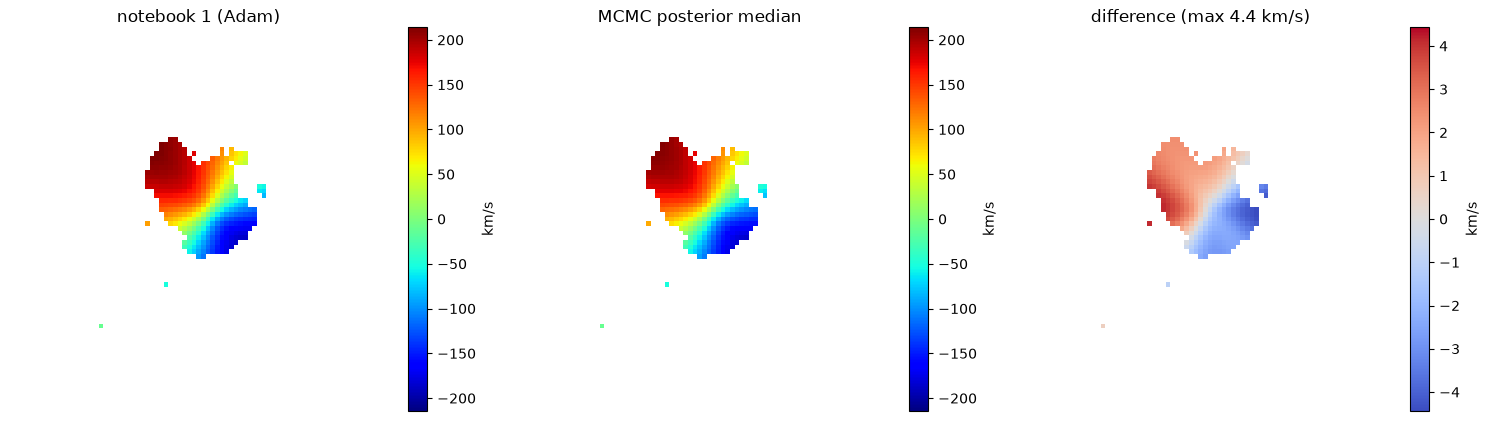

In [60]:
# velocity fields side by side, and their difference
def vfield(p):
    v = kinematics.arctangent_disk_velocity_model(
        x, y, *[torch.tensor(float(p[f'velocity.{k}']))
                for k in ('V_rot', 'R_v', 'x0_v', 'y0_v', 'theta_v', 'inc_v')]
    ).detach().cpu().numpy()
    out = v.copy(); out[~mask] = np.nan
    return out

mcmc_params = {n: np.median(flat[:, names.index(n)]) for n in names}
if 'velocity.inc_v' not in mcmc_params:
    mcmc_params['velocity.inc_v'] = FIXED_INC_RAD
v1_field, vm_field = vfield(NOTEBOOK_1_PARAMS), vfield(mcmc_params)
vmax = np.nanmax(np.abs(v1_field))
dmax = np.nanmax(np.abs(v1_field - vm_field))

fig, axs = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, im, t, kw in [
        (axs[0], v1_field, 'notebook 1 (Adam)',   dict(cmap='jet', vmin=-vmax, vmax=vmax)),
        (axs[1], vm_field, 'MCMC posterior median', dict(cmap='jet', vmin=-vmax, vmax=vmax)),
        (axs[2], v1_field - vm_field, f'difference (max {dmax:.1f} km/s)',
         dict(cmap='coolwarm', vmin=-dmax, vmax=dmax))]:
    m = ax.imshow(im, origin='lower', **kw)
    ax.set_title(t); ax.grid(False); ax.set_axis_off()
    fig.colorbar(m, ax=ax, fraction=0.046, label='km/s')
plt.tight_layout(); plt.gcf().savefig(out('velocity_field_comparison.png'), dpi=130, bbox_inches='tight')
plt.tight_layout(); plt.show()

## What the posterior median actually fits

Push the posterior-median parameters back through the forward model to get the rectified
images, the velocity fields, and the R-C residual the likelihood is built on. Same four
panels as the Adam fit above, so the two are directly comparable.

posterior MAP sample: {'velocity.V_rot': 458.9031, 'velocity.R_v': 3.3292, 'velocity.x0_v': 42.5734, 'velocity.y0_v': 41.6185} ...


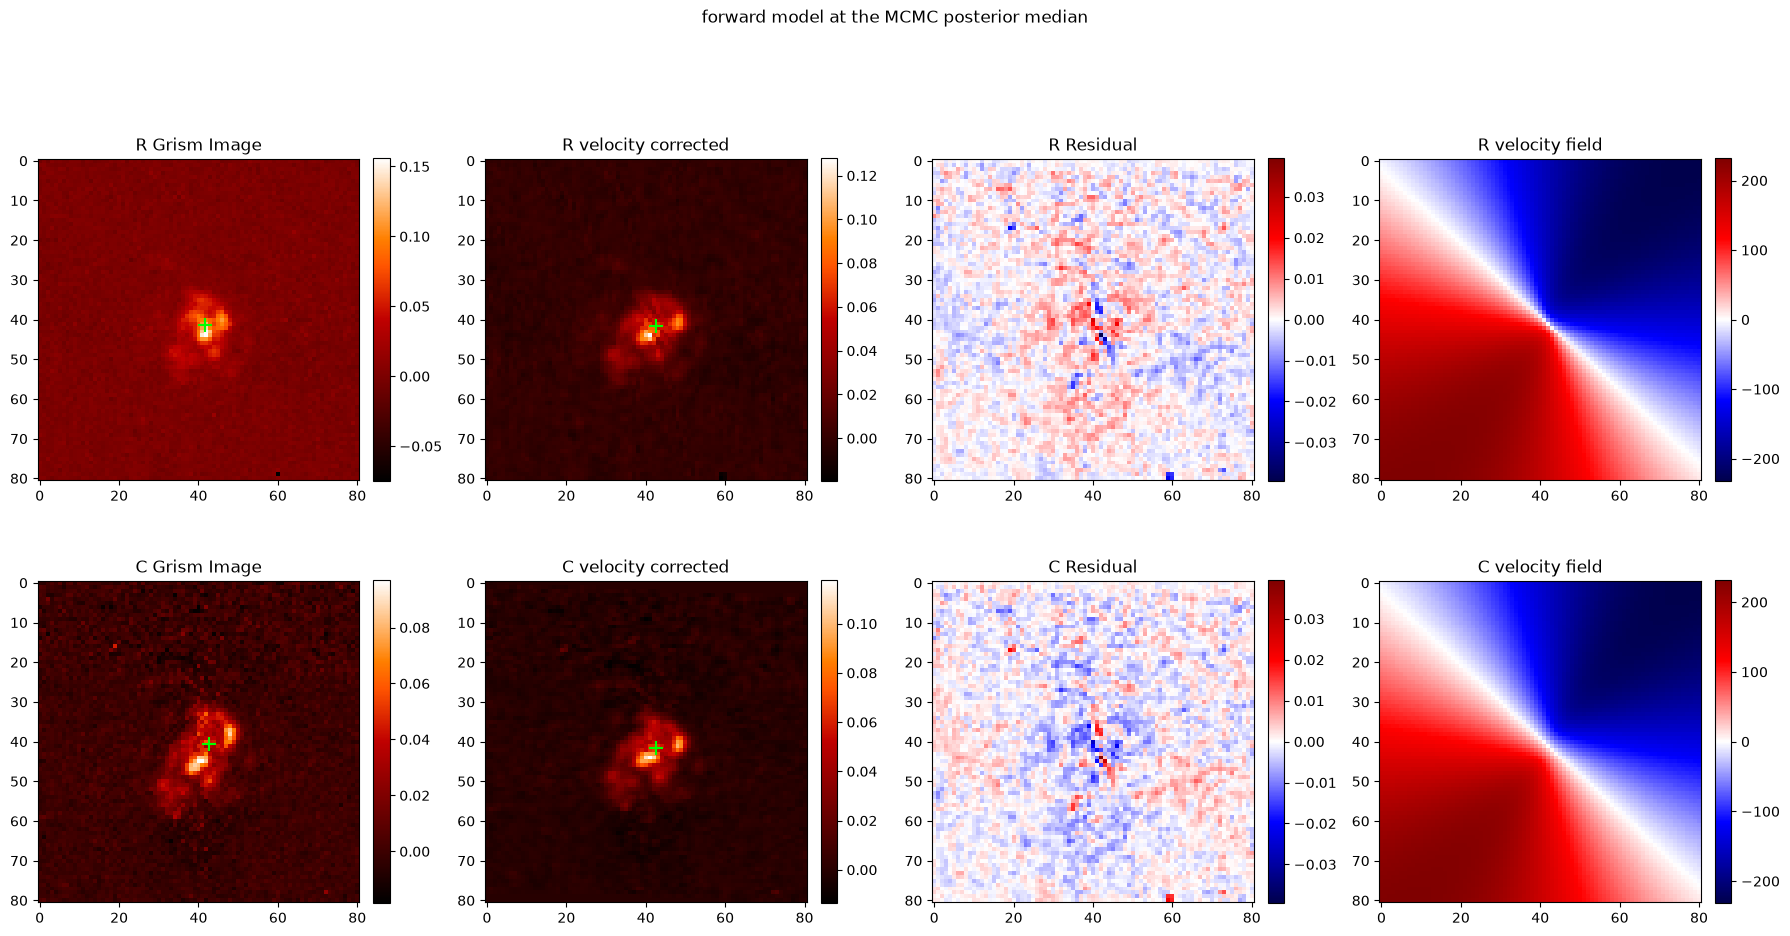

In [61]:
# Two summaries of ONE posterior. There is a single true kinematics; these are two
# ways of collapsing our uncertainty about it to a single parameter vector:
#   median -- the 50th percentile of each parameter's marginal, taken independently.
#             Not necessarily a point the chain visited, and for a curved (banana)
#             posterior it can sit off the ridge.
#   MAP    -- the single sampled point with the highest log-probability. Always a
#             real point, and the right thing to RENDER a model image from.
# If their residuals differ visibly, the posterior is badly shaped -- that is the
# diagnostic, not a physical difference.
def _forward_at(params):
    kinematics_fitter.set_params_dict(params)
    kinematics_fitter._reset_state()
    with torch.no_grad():
        kinematics_fitter.loss()
    return (kinematics_fitter.get_fitting_results(), kinematics_fitter.get_params())

imap_ = int(np.argmax(saved['log_prob'][nburn:].reshape(-1)))
map_params = {n: float(flat[imap_, j]) for j, n in enumerate(names) if n in mcmc_params}
print('posterior MAP sample:', {k: round(v, 4) for k, v in list(map_params.items())[:4]}, '...')

(image_R_mp, image_C_mp, vz_R_mp, vz_C_mp), (vel_mp, disp_R_mp, disp_C_mp) = _forward_at(map_params)
(image_R_mc, image_C_mc, vz_R_mc, vz_C_mc), (vel_mc, disp_R_mc, disp_C_mc) = _forward_at(mcmc_params)

fig, axs = plt.subplots(2, 4, figsize=(18, 10))
plot.plot_kinematics_fitting_result(true_grism_R, image_R_mc, vz_R_mc, image_C_mc, 'R',
                                    axs[0], vel_mc, disp_R_mc)
plot.plot_kinematics_fitting_result(true_grism_C, image_C_mc, vz_C_mc, image_R_mc, 'C',
                                    axs[1], vel_mc, disp_C_mc)
fig.suptitle('forward model at the MCMC posterior median', y=1.005)
plt.tight_layout(); plt.gcf().savefig(out('fit_panels_mcmc_median.png'), dpi=130, bbox_inches='tight')
plt.tight_layout(); plt.show()

12:01:06 - INFO - dingo.fitting - [MCMC] noise model frozen: sigma_R=0.0037841 sigma_C=0.0038251 var_base=2.8951e-05 N_pix=6297/6561 (mask drops 1.6% of the flux)
12:01:06 - [MCMC] noise model frozen: sigma_R=0.0037841 sigma_C=0.0038251 var_base=2.8951e-05 N_pix=6297/6561 (mask drops 1.6% of the flux)


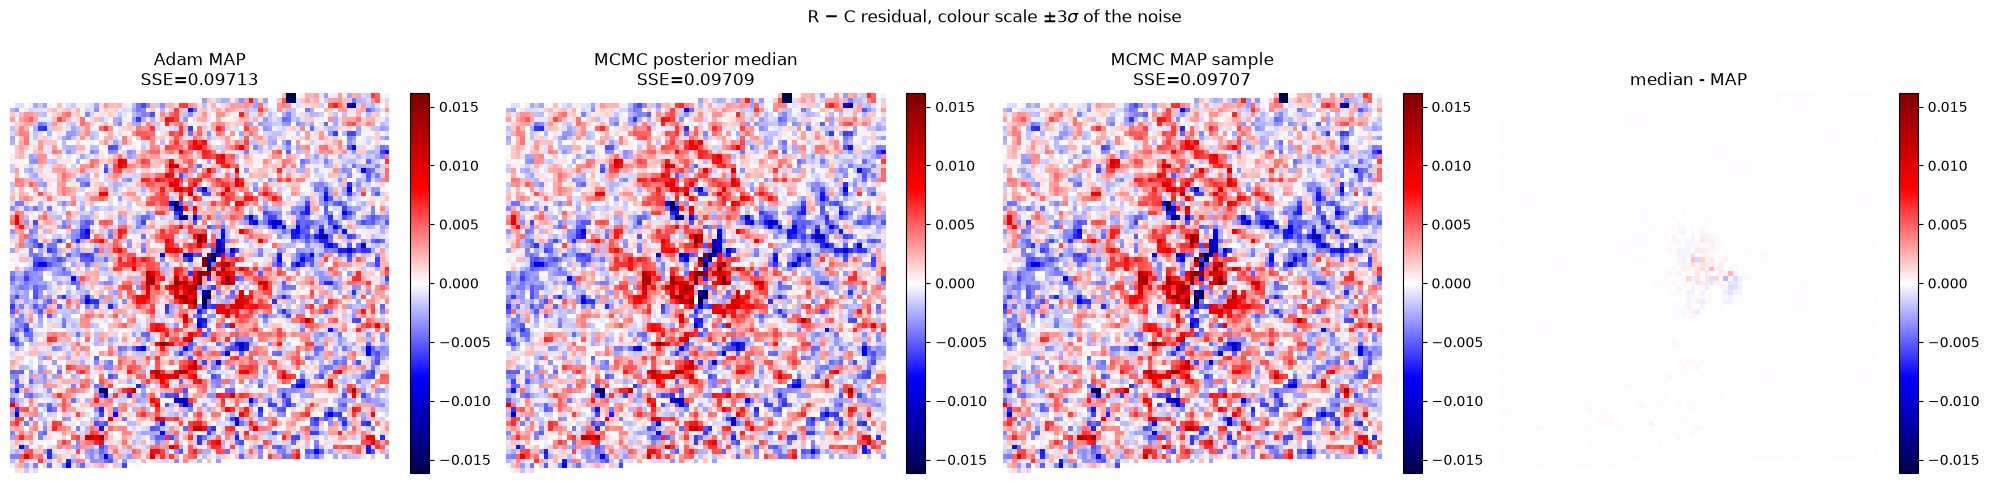

                SSE (masked)    chi2/N   resid rms
Adam MAP             0.09713    0.5328    0.003893
MCMC median          0.09709    0.5326    0.003892
MCMC MAP             0.09707    0.5325    0.003892

mask keeps 6297 of 6561 pixels; sigma_R-C = 0.005381


In [62]:
# the R-C residual: what the likelihood actually sums over
def _np(a):
    '''get_fitting_results() returns ndarrays; loss() caches tensors. Take either.'''
    return a.detach().cpu().numpy() if hasattr(a, 'detach') else np.asarray(a)

resid_adam = _np(image_R)    - _np(image_C)
resid_mcmc = _np(image_R_mc) - _np(image_C_mc)

nmask = getattr(kinematics_fitter, 'mcmc_mask', None)
if nmask is None:
    kinematics_fitter.setup_noise_model()
    nmask = kinematics_fitter.mcmc_mask
nmask = _np(nmask).astype(bool)
sigma = float(np.sqrt(kinematics_fitter.mcmc_var_base))

resid_map = _np(image_R_mp) - _np(image_C_mp)

# Common colour scale so the three panels are honestly comparable, and a scale set by
# the NOISE (not by the residual) so "is this structure real?" is answerable by eye:
# +-3 sigma of the R-C difference. Anything saturating is not noise.
scale = 3*sigma
show = lambda r: np.where(nmask, r, np.nan)
panels = [(show(resid_adam), 'Adam MAP'),
          (show(resid_mcmc), 'MCMC posterior median'),
          (show(resid_map),  'MCMC MAP sample'),
          (show(resid_mcmc - resid_map), 'median - MAP')]

fig, axs = plt.subplots(1, 4, figsize=(20, 4.6))
for ax, (im, t) in zip(axs, panels):
    m = ax.imshow(im, origin='lower', cmap='seismic', vmin=-scale, vmax=scale)
    sse = float(np.nansum(np.where(nmask, im, 0.0)**2))
    ax.set_title(f'{t}\nSSE={sse:.5f}' if 'median - MAP' not in t else t)
    ax.grid(False); ax.set_axis_off()
    fig.colorbar(m, ax=ax, fraction=0.046)
fig.suptitle(r'R $-$ C residual, colour scale $\pm3\sigma$ of the noise', y=1.04)
plt.tight_layout(); plt.gcf().savefig(out('residual_RminusC.png'), dpi=130, bbox_inches='tight')
plt.show()

print(f'{"":<14}{"SSE (masked)":>14}{"chi2/N":>10}{"resid rms":>12}')
for label, r in [('Adam MAP', resid_adam), ('MCMC median', resid_mcmc),
                 ('MCMC MAP', resid_map)]:
    sse = float(np.sum(r[nmask]**2))
    print(f'{label:<14}{sse:>14.5f}{sse/(nmask.sum()*sigma**2):>10.4f}'
          f'{np.std(r[nmask]):>12.6f}')
print(f'\nmask keeps {nmask.sum()} of {nmask.size} pixels; '
      f'sigma_R-C = {sigma:.6f}')

# restore the Adam MAP so later cells are unaffected
kinematics_fitter.set_params_dict({k: adam[k] for k in mcmc_params if k in adam})
kinematics_fitter._reset_state()
with torch.no_grad():
    kinematics_fitter.loss()

## Batch: run every source from here

`run_source()` is the whole per-source pipeline as one call -- generate the config,
Adam fit, freeze the noise model, sample, save to `results/ID<n>/`, return the derived
quantities. Set `BATCH_IDS` at the top of the notebook and run the cell below; nothing
needs to happen at a terminal.

`nsteps=None` uses the config value (8000, ~2.5 h per source). Drop it to a few hundred
for a smoke test first -- the fit is what usually fails, not the sampler.

In [63]:
def run_source(sid, nsteps=None, nburn=None, inc_prior=None, save=True, plots=False):
    '''Full pipeline for one source. Returns a dict of derived quantities.'''
    outdir = os.path.join(RESULTS, f'ID{sid}')
    os.makedirs(outdir, exist_ok=True)
    cfg = f'ID{sid}/config_kinematics.yaml'
    if not os.path.exists(os.path.join(DATA, cfg)):
        make_config(sid)

    src_i = lookup_source(sid)
    f = fitting.KinematicsFitter(config_path=cfg)
    f.fit_all()

    if inc_prior is not None:                     # (mu, sigma) in radians
        mu, sg = inc_prior
        f.config.setdefault('mcmc', {}).setdefault('priors', {})['velocity.inc_v'] = {
            'type': 'gaussian', 'mu': float(mu), 'sigma': float(sg),
            'min': 0.0873, 'max': 1.4835}

    f.setup_noise_model()
    f.fit_MCMC(nsteps=nsteps, nburn=nburn)
    chain_path = os.path.join(outdir, f'ID{sid}_chain.npz')
    if save:
        f.save_mcmc(chain_path)

    names = f.mcmc_param_names
    flat = f.mcmc_chain
    gi = {n: names.index(n) for n in names}
    V = flat[:, gi['velocity.V_rot']]
    inc = flat[:, gi['velocity.inc_v']]
    Rv = flat[:, gi['velocity.R_v']]
    kpp = kpc_per_pixel(src_i['zspec'])
    vsini = V*np.sin(inc)
    mdyn = np.log10(arctangent_dynamical_mass(5.0, V, Rv*kpp))

    q = lambda a: np.percentile(a, [16, 50, 84])
    row = {'id': sid, 'z': src_i['zspec'], 'kpc_per_pix': kpp,
           'loss': float(f.loss()), 'acc': float(np.mean(f.mcmc_sampler.acceptance_fraction)),
           'railed_inc': bool(np.median(inc) < 0.10 or np.median(inc) > 1.45)}
    for label, arr in [('V_rot', V), ('inc_v', inc), ('Vsini', vsini),
                       ('R_v_kpc', Rv*kpp), ('logM5', mdyn)]:
        lo, me, hi = q(arr)
        row[label], row[label+'_lo'], row[label+'_hi'] = me, me-lo, hi-me
    if save:
        # `row` already holds scalar Vsini/logM5/R_v_kpc summaries, so prefix the
        # full sample arrays rather than colliding with those keyword names.
        np.savez_compressed(
            os.path.join(outdir, f'ID{sid}_derived.npz'),
            samples_Vsini=vsini, samples_logM5=mdyn, samples_R_v_kpc=Rv*kpp,
            **{k: v for k, v in row.items() if not isinstance(v, bool)})
    if plots:
        plot.plot_mcmc_corner(flat, names)
    return row

In [64]:
if BATCH_IDS:
    rows = []
    for sid in BATCH_IDS:
        print(f'\n{"="*64}\nID {sid}\n{"="*64}')
        try:
            rows.append(run_source(sid))
        except Exception as exc:
            print(f'ID {sid} FAILED: {type(exc).__name__}: {exc}')

    hdr = (f'{"ID":>7}{"z":>8}{"V_rot":>9}{"inc deg":>9}{"Vsini":>9}'
           f'{"+-":>7}{"logM5":>8}{"acc":>7}  flag')
    print('\n' + hdr); print('-'*len(hdr))
    for r in rows:
        flag = 'INC RAILED' if r['railed_inc'] else ''
        print(f'{r["id"]:>7}{r["z"]:>8.4f}{r["V_rot"]:>9.1f}'
              f'{np.rad2deg(r["inc_v"]):>9.1f}{r["Vsini"]:>9.1f}'
              f'{0.5*(r["Vsini_lo"]+r["Vsini_hi"]):>7.1f}{r["logM5"]:>8.3f}'
              f'{r["acc"]:>7.3f}  {flag}')
else:
    print('BATCH_IDS is empty -- set it at the top of the notebook to run more sources.')

BATCH_IDS is empty -- set it at the top of the notebook to run more sources.


## Headline result

`V*sin(i)` is what the grism data measure directly. To get `V_rot` you divide by
`sin(i)`, and the inclination comes from the imaging -- so the error budget has two
parts, and the second one dominates:

- **statistical**, from the MCMC posterior on `V*sin(i)` (a few km/s)
- **inclination systematic**, from `dV/V = cot(i) * di`, using the scatter BETWEEN
  independent morphology methods rather than any single fit's formal error

`INC_METHOD_SCATTER` below is the honest width: a single pysersic fit reports ~0.01 rad,
which is far too tight for a galaxy a single Sersic cannot describe.

In [65]:
INC_METHOD_SCATTER = FIXED_INC_SIGMA if FIX_INCLINATION else 0.044

i_phot = (FIXED_INC_RAD if FIX_INCLINATION else
           (PYSERSIC_INC if PYSERSIC_INC is not None else np.median(flat[:, iI])))
di = (INC_METHOD_SCATTER if FIX_INCLINATION else
      max(PYSERSIC_INC_SIG_FORMAL or 0.0, INC_METHOD_SCATTER))

vs_lo, vs_med, vs_hi = np.percentile(Vsini, [16, 50, 84])
vs_err = 0.5*(vs_hi - vs_lo)

V_cond = vs_med/np.sin(i_phot)
V_stat = vs_err/np.sin(i_phot)                     # grism uncertainty
V_sys = V_cond/np.tan(i_phot)*di                   # inclination uncertainty

# The kinematic chain is conditional on the fixed median i. Propagate the full
# pysersic posterior plus the method-to-method morphology scatter into V_rot.
if FIX_INCLINATION:
    _rng = np.random.default_rng(15665)
    _i_draws = _rng.choice(PYSERSIC_INC_SAMPLES, size=Vsini.size, replace=True)
    _i_draws = np.clip(_i_draws + _rng.normal(0.0, METHOD_SCATTER, Vsini.size),
                       0.0873, 1.4835)
    Vrot_propagated = Vsini/np.sin(_i_draws)
    inc_samples_for_headline = _i_draws
else:
    Vrot_propagated = V
    inc_samples_for_headline = inc
Vlo, V_phot, Vhi = np.percentile(Vrot_propagated, [16, 50, 84])

R_v_samples_kpc = flat[:, iR]*KPC_PER_PIX
R_v_kpc = np.median(R_v_samples_kpc)
logM_samples = np.log10(arctangent_dynamical_mass(
    5.0, Vrot_propagated, R_v_samples_kpc))
logMlo, logM, logMhi = np.percentile(logM_samples, [16, 50, 84])
dlogM_stat = 2*V_stat/V_phot/np.log(10)
dlogM_sys = 2*V_sys/V_phot/np.log(10)

print(f'ID {ID}   z = {z:.4f}   {KPC_PER_PIX:.4f} kpc/pixel\n')
print(f'  V*sin(i)              = {vs_med:8.2f} +- {vs_err:.2f} km/s     (measured)')
print(f'  inclination           = {np.degrees(i_phot):8.2f} +- {np.degrees(di):.2f} deg'
      f'      (adopted imaging)')
print(f'  V_rot                 = {V_phot:8.1f} -{V_phot-Vlo:.1f}/+{Vhi-V_phot:.1f} km/s '
      f'(MCMC + inclination marginalized)')
print(f'    components          = +- {V_stat:.1f} (conditional MCMC) and '
      f'~+- {V_sys:.1f} (linear inclination estimate)')
print(f'  R_v                   = {R_v_kpc:8.3f} kpc')
print(f'  log10 M_dyn(<5 kpc)   = {logM:8.3f} +- {dlogM_stat:.3f} (stat) '
      f'+- {dlogM_sys:.3f} (incl) dex')
print(f'\n  inclination dominates: {V_sys/V_stat:.0f}x the statistical error on V_rot')

# For a fixed-i run there is no independent kinematic-only inclination.
if iI is not None:
    i_kin = np.median(flat[:, iI])
    print(f'\n  kinematic-only inclination = {np.degrees(i_kin):.2f} deg '
          f'-> V_rot = {vs_med/np.sin(i_kin):.1f} km/s')
else:
    print('\n  inclination was fixed; no kinematic-only inclination is estimated')

np.savez_compressed(out('headline.npz'),
                    Vsini=vs_med, Vsini_err=vs_err, inc_phot=i_phot, inc_err=di,
                    V_rot=V_phot, V_rot_lo=V_phot-Vlo, V_rot_hi=Vhi-V_phot,
                    V_rot_conditional=V_cond, V_rot_stat=V_stat, V_rot_sys=V_sys,
                    R_v_kpc=R_v_kpc, logM5=logM,
                    logM5_stat=dlogM_stat, logM5_sys=dlogM_sys, z=z)
print('\nsaved ->', out('headline.npz'))
np.savez_compressed(out('derived_posterior.npz'),
                    Vsini=Vsini, Vrot_conditional=V,
                    Vrot_marginal=Vrot_propagated,
                    inc_marginal=inc_samples_for_headline,
                    R_v_kpc=R_v_samples_kpc)
print('saved ->', out('derived_posterior.npz'))

ID 15665   z = 1.1613   0.5198 kpc/pixel

  V*sin(i)              =   241.85 +- 1.97 km/s     (measured)
  inclination           =    31.80 +- 2.50 deg      (adopted imaging)
  V_rot                 =    459.2 -29.9/+35.3 km/s (MCMC + inclination marginalized)
    components          = +- 3.7 (conditional MCMC) and ~+- 32.3 (linear inclination estimate)
  R_v                   =    1.747 kpc
  log10 M_dyn(<5 kpc)   =   11.180 +- 0.007 (stat) +- 0.061 (incl) dex

  inclination dominates: 9x the statistical error on V_rot

  inclination was fixed; no kinematic-only inclination is estimated

saved -> /Users/aakavan/Astro_Research/Galaxy_Kinematics/DINGO_development/grism-kinematics/results/ID15665/ID15665_headline.npz
saved -> /Users/aakavan/Astro_Research/Galaxy_Kinematics/DINGO_development/grism-kinematics/results/ID15665/ID15665_derived_posterior.npz


## Summary

This notebook runs the focused pipeline from catalogue lookup -> Adam fit -> broad-prior MCMC posterior -> derived quantities. The sampler uses the same full-image R-minus-C SSE as Adam, while the posterior is explored from the configured broad proper priors. Poster plots are in `poster-plots.ipynb`.

The R-C offset parameterization is intentionally unchanged so any registration degeneracy remains visible in the posterior. See `../MCMC_STATUS.md`.

In [66]:
print(f'{"quantity":<28}{"median":>12}{"-1sigma":>10}{"+1sigma":>10}')
inc_summary = inc_marginal if FIX_INCLINATION else flat[:, iI]
rv_summary = flat[:, iR]*KPC_PER_PIX
rows = [('V_rot [km/s] (marginalized)', Vrot_marginal),
        ('V_rot [km/s] (fixed i)',       V),
        ('inc_v [rad] (adopted)',        inc_summary),
        ('inc_v [deg] (adopted)',        np.rad2deg(inc_summary)),
        ('V sin(i) [km/s]',              Vsini),
        ('R_v [kpc]',                    rv_summary),
        ('log10 M_dyn(<5kpc)', np.log10(arctangent_dynamical_mass(
            5.0, Vrot_marginal, rv_summary)))]
for label, s in rows:
    a, b, c = np.percentile(s, [16, 50, 84])
    print(f'{label:<28}{b:>12.4f}{b-a:>10.4f}{c-b:>10.4f}')

quantity                          median   -1sigma   +1sigma
V_rot [km/s] (marginalized)     459.1612   29.8825   35.3313
V_rot [km/s] (fixed i)          458.9093    3.6746    3.8180
inc_v [rad] (adopted)             0.5549    0.0434    0.0432
inc_v [deg] (adopted)            31.7917    2.4863    2.4777
V sin(i) [km/s]                 241.8452    1.9365    2.0121
R_v [kpc]                         1.7468    0.0390    0.0389
log10 M_dyn(<5kpc)               11.1800    0.0581    0.0642
